In [16]:
import freesasa

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from Bio import SeqIO, PDB

import glob

In [18]:
import os
os.environ['QT_QPA_PLATFORM'] = 'offscreen'

In [19]:
metrics_df = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_full.tsv.gz', sep='\t')
filtered = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_filtered.tsv.gz', sep='\t')

In [20]:
pdbs = glob.glob('./../data/processed_structures/*.pdb')

In [21]:
pdbs[:5]

['./../data/processed_structures/GB_GCA_001054945.1_A_processed.pdb',
 './../data/processed_structures/GB_GCA_000717275.1_A_processed.pdb',
 './../data/processed_structures/GB_GCA_001187505.1_A_processed.pdb',
 './../data/processed_structures/GB_GCA_000376885.1_A_processed.pdb',
 './../data/processed_structures/GB_GCA_000411155.1_A_processed.pdb']

In [94]:
def compute_delta_sasa_freesasa(pdb_file):
    """
    Compute delta SASA using FreeSASA
    """
    # Load structure
    structure = freesasa.Structure(pdb_file)
    
    # Calculate SASA for folded state
    folded_result = freesasa.calc(structure)
    
    # Get per-residue SASA
    classifier = freesasa.Classifier()
    folded_sasa_by_residue = {}
    
    for i in range(structure.nAtoms()):
        atom = structure.atomName(i)
        residue_number = structure.residueNumber(i)
        residue_name = structure.residueName(i)
        
        if residue_number not in folded_sasa_by_residue:
            folded_sasa_by_residue[residue_number] = {
                'name': residue_name,
                'sasa': 0.0
            }
        
        folded_sasa_by_residue[residue_number]['sasa'] += folded_result.atomArea(i)
    
    # Reference values (Tien et al. 2013, or Miller et al. 1987)
    reference_sasa = {
        'ALA': 129.0, 'ARG': 274.0, 'ASN': 195.0, 'ASP': 193.0,
        'CYS': 167.0, 'GLU': 223.0, 'GLN': 225.0, 'GLY': 104.0,
        'HIS': 224.0, 'ILE': 197.0, 'LEU': 201.0, 'LYS': 236.0,
        'MET': 224.0, 'PHE': 240.0, 'PRO': 159.0, 'SER': 155.0,
        'THR': 172.0, 'TRP': 285.0, 'TYR': 263.0, 'VAL': 174.0
    }
    
    # Calculate delta SASA
    delta_sasa = {}
    for res_num, res_data in folded_sasa_by_residue.items():
        res_name = res_data['name']
        if res_name in reference_sasa:
            delta_sasa[res_num] = reference_sasa[res_name] - res_data['sasa']
    
    return delta_sasa


def compute_residue_sasa_and_delta(pdb_file):
    """
    Compute per-residue solvent-accessible surface area (SASA) and ΔSASA
    using FreeSASA.

    Parameters
    ----------
    pdb_file : str
        Path to PDB file.

    Returns
    -------
    dict
        Dictionary mapping residue number → {
            'resname': str,
            'sasa': float,
            'delta_sasa': float
        }
    """

    # Load structure and compute SASA
    structure = freesasa.Structure(pdb_file)
    result = freesasa.calc(structure)

    # Reference SASA values for fully exposed residues (Å²)
    # Source: Tien et al. 2013 or Miller et al. 1987
    reference_sasa = {
        'ALA': 129.0, 'ARG': 274.0, 'ASN': 195.0, 'ASP': 193.0,
        'CYS': 167.0, 'GLU': 223.0, 'GLN': 225.0, 'GLY': 104.0,
        'HIS': 224.0, 'ILE': 197.0, 'LEU': 201.0, 'LYS': 236.0,
        'MET': 224.0, 'PHE': 240.0, 'PRO': 159.0, 'SER': 155.0,
        'THR': 172.0, 'TRP': 285.0, 'TYR': 263.0, 'VAL': 174.0
    }

    # Aggregate per-residue SASA
    sasa_by_residue = {}
    for i in range(structure.nAtoms()):
        res_num = structure.residueNumber(i)
        res_name = structure.residueName(i)

        if res_num not in sasa_by_residue:
            sasa_by_residue[res_num] = {'resname': res_name, 'sasa': 0.0}

        sasa_by_residue[res_num]['sasa'] += result.atomArea(i)

    # Compute ΔSASA (difference from reference)
    for res_num, res_data in sasa_by_residue.items():
        res_name = res_data['resname']
        sasa = res_data['sasa']
        if res_name in reference_sasa:
            delta = reference_sasa[res_name] - sasa
        else:
            delta = None  # unknown residue type
        res_data['delta_sasa'] = delta
    
    return sasa_by_residue

def compute_normalized_delta_sasa(pdb_file):
    """
    Compute normalized delta SASA (0 = fully buried, 1 = fully exposed)
    """
    delta_sasa = compute_delta_sasa_freesasa(pdb_file)
    
    # Reference SASA values
    reference_sasa = {
        'ALA': 129.0, 'ARG': 274.0, 'ASN': 195.0, 'ASP': 193.0,
        'CYS': 167.0, 'GLU': 223.0, 'GLN': 225.0, 'GLY': 104.0,
        'HIS': 224.0, 'ILE': 197.0, 'LEU': 201.0, 'LYS': 236.0,
        'MET': 224.0, 'PHE': 240.0, 'PRO': 159.0, 'SER': 155.0,
        'THR': 172.0, 'TRP': 285.0, 'TYR': 263.0, 'VAL': 174.0
    }
    
    normalized_delta_sasa = {}
    for res_num, delta_val in delta_sasa.items():
        # Need to get residue name for normalization
        # This is simplified - you'd need to get actual residue name
        res_name = 'ALA'  # placeholder
        if res_name in reference_sasa:
            normalized_delta_sasa[res_num] = delta_val / reference_sasa[res_name]
    
    return normalized_delta_sasa

## outline
Compute a deltaSASA for the residues in each protein and see whether the average change of the residues is correlated with higher or lower thermostability

In [17]:
test_dataset = filtered.groupby('temp').apply(lambda x: x.sample(np.min([100, len(x)]), replace=False))

In [18]:
df_list = []
for p in pdbs:
    uid =  p.split('/')[-1].split('_A_')[0]
    if uid in test_dataset['uid'].unique():
        df_list.append(pd.Series(compute_normalized_delta_sasa(p), name=uid))

test_df = pd.concat(df_list, axis=1)
test_df.head()

,GB_GCA_001749745.1,RS_GCF_000427905.1,RS_GCF_000379025.1,RS_GCF_000023825.1,RS_GCF_000213255.1,RS_GCF_000242915.1,RS_GCF_000517025.1,RS_GCF_001418005.1,RS_GCF_000014725.1,RS_GCF_000178835.2,...,RS_GCF_902459735.1,RS_GCF_900536025.1,RS_GCF_900566055.1,RS_GCF_902459765.1,RS_GCF_900566075.1,RS_GCF_902459805.1,RS_GCF_902499555.1,RS_GCF_900606115.1,RS_GCF_902499125.1,RS_GCF_902804485.1
1,1.121268,NaN,1.253346,0.991487,1.155460,1.139857,1.115837,1.268971,1.169207,1.283976,...,1.314481,1.301405,1.284606,1.299036,1.245111,1.283554,0.797266,1.275181,1.314428,0.860278
2,1.295136,0.518896,1.431592,1.181297,1.329010,1.558389,1.416331,1.786367,1.454736,1.795096,...,1.443717,1.551883,1.826351,1.463084,1.814119,1.467270,1.011680,1.549162,1.448148,1.182927
3,1.540414,1.147235,1.558140,1.511628,1.527132,1.527132,1.556067,1.557991,1.522914,1.558140,...,1.558140,1.345457,1.348837,1.558140,1.348743,1.558140,1.511628,1.558140,1.558140,1.511628
4,1.348837,2.035079,1.527132,1.839351,1.348696,1.527132,1.348837,1.527132,1.520357,1.527132,...,1.503874,1.527132,1.347329,1.504616,1.346843,1.527132,1.518531,1.522790,1.519535,1.527132
5,1.842610,1.537511,1.547718,1.342239,1.548831,1.537654,1.543362,1.551198,1.533423,1.541451,...,1.541247,1.543162,1.542032,1.529617,1.543653,1.541362,1.340346,1.547677,1.542432,1.348113


<Axes: xlabel='None', ylabel='temp'>

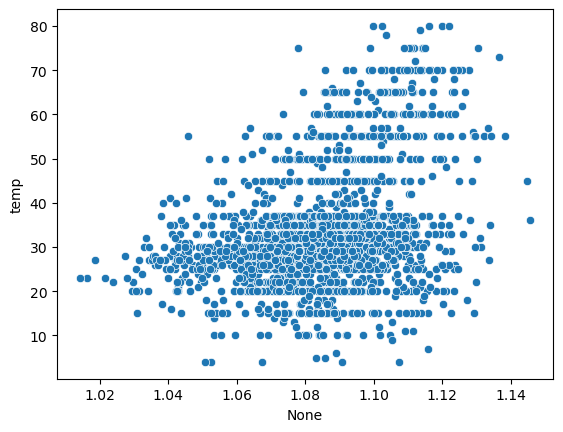

In [19]:
sns.scatterplot(x=test_df.mean(), y=test_dataset.set_index('uid')['temp'])

In [20]:
with open('./../data/20240122_all_adks_filtered_nogap.afa', 'r') as handle:
    lines = [pd.Series(index=range(len(r.seq)), data=[i for i in str(r.seq)], name=r.id) for r in SeqIO.parse(handle, 'fasta')]

aln_df = pd.concat(lines, axis=1).T

def translate_with_gaps(nuc_seq):
    return [
        str(Seq(codon).translate()) if '-' not in codon and len(codon) == 3 else '-'
        for codon in [nuc_seq[i:i+3] for i in range(0, len(nuc_seq), 3)]
    ]

# aln_df = pd.concat([aln_df, anc_trim_df]).fillna('-')

aln_df.head()

aln_df.index = [s.split('|')[1] for s in aln_df.index]

In [28]:
# Convert to numpy for speed
sasa_array = test_df.T.values

# Handle NaN values by filling with column means
col_means = np.nanmean(sasa_array, axis=0)
sasa_filled = np.where(np.isnan(sasa_array), col_means, sasa_array)

window_averages = uniform_filter1d(
    sasa_filled, 
    size=39, 
    axis=1, 
    mode='constant'
)

In [31]:
# sns.histplot(
pd.DataFrame(data=window_averages, index=test_df.T.index).apply(lambda x: pearsonr(x, test_dataset.set_index('uid')['temp'].reindex(index=x.index))[0], axis=0).idxmax()
            # )

192

<Axes: xlabel='192', ylabel='temp'>

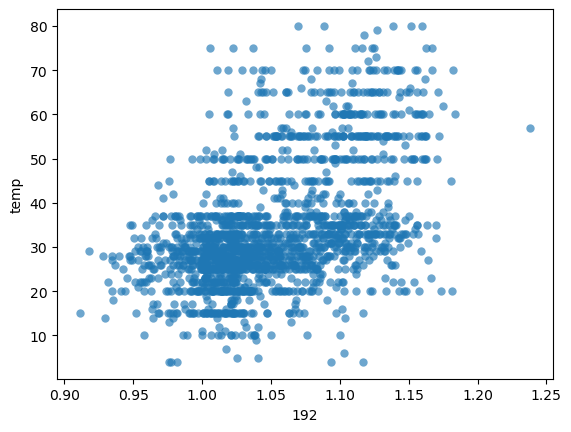

In [37]:
sns.scatterplot(x=pd.DataFrame(data=window_averages, index=test_df.T.index).loc[:, 192],
                y= test_dataset.set_index('uid')['temp'], linewidth=0, alpha=0.65)

In [50]:
sasa_filled

array([[1.25334636, 1.43159196, 1.55813953, ..., 1.13441848, 1.45457182,
        0.02099583],
       [1.3358836 , 1.76934596, 1.52713178, ..., 1.13441848, 1.45457182,
        0.02099583],
       [1.15546046, 1.32901012, 1.52713178, ..., 1.13441848, 1.45457182,
        0.02099583],
       ...,
       [1.28355352, 1.46726975, 1.55813953, ..., 1.13441848, 1.45457182,
        0.02099583],
       [0.79726611, 1.01167984, 1.51162791, ..., 1.13441848, 1.45457182,
        0.02099583],
       [0.86027754, 1.18292725, 1.51162791, ..., 1.13441848, 1.45457182,
        0.02099583]])

In [32]:

from scipy.stats import pearsonr, spearmanr
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

class SASAWindowAnalyzer:
    """
    Efficiently analyze SASA windows for correlation with traits
    """
    
    def __init__(self, sasa_df: pd.DataFrame, traits: pd.Series, 
                 max_window_size: int = 50, min_window_size: int = 3):
        """
        Initialize analyzer
        
        Parameters:
        -----------
        sasa_df : pd.DataFrame
            DataFrame with proteins as rows, residue positions as columns
            Contains delta SASA values
        traits : pd.Series
            Series with protein names as index, trait values as values
        max_window_size : int
            Maximum window size to test
        min_window_size : int
            Minimum window size to test
        """
        self.sasa_df = sasa_df
        self.traits = traits
        self.max_window_size = max_window_size
        self.min_window_size = min_window_size
        
        # Align data
        common_proteins = list(set(sasa_df.index) & set(traits.index))
        self.sasa_df = sasa_df.loc[common_proteins]
        self.traits = traits.loc[common_proteins]
        
        # Results storage
        self.results = []
        self.best_windows = {}
        
    def compute_sliding_windows_vectorized(self, window_size: int) -> np.ndarray:
        """
        Compute all sliding window averages efficiently using convolution
        
        Parameters:
        -----------
        window_size : int
            Size of sliding window
            
        Returns:
        --------
        np.ndarray
            Array of shape (n_proteins, n_positions - window_size + 1)
            Each element is the average SASA for that window
        """
        # Convert to numpy for speed
        sasa_array = self.sasa_df.values
        
        # Handle NaN values by filling with column means
        col_means = np.nanmean(sasa_array, axis=0)
        sasa_filled = np.where(np.isnan(sasa_array), col_means, sasa_array)
        
        # Use uniform_filter1d for efficient sliding window computation
        # This is equivalent to convolution but faster
        window_averages = uniform_filter1d(
            sasa_filled, 
            size=window_size, 
            axis=1, 
            mode='constant'
        )
        
        # Trim to valid windows only
        valid_positions = sasa_filled.shape[1] - window_size + 1
        return window_averages[:, :valid_positions]
    
    def analyze_window_size(self, window_size: int, correlation_method: str = 'pearson') -> Dict:
        """
        Analyze all windows of a given size
        
        Parameters:
        -----------
        window_size : int
            Size of window to analyze
        correlation_method : str
            'pearson' or 'spearman'
            
        Returns:
        --------
        Dict containing results for this window size
        """
        # Get all window averages
        window_averages = self.compute_sliding_windows_vectorized(window_size)
        
        # Compute correlations for each window position
        n_windows = window_averages.shape[1]
        correlations = np.zeros(n_windows)
        p_values = np.zeros(n_windows)
        
        trait_values = self.traits.values
        
        for i in range(n_windows):
            window_sasa = window_averages[:, i]
            
            # Remove any remaining NaN values
            valid_mask = ~np.isnan(window_sasa) & ~np.isnan(trait_values)
            
            if np.sum(valid_mask) > 3:  # Need at least 4 points for correlation
                if correlation_method == 'pearson':
                    corr, p_val = pearsonr(window_sasa[valid_mask], trait_values[valid_mask])
                else:
                    corr, p_val = spearmanr(window_sasa[valid_mask], trait_values[valid_mask])
                
                correlations[i] = corr
                p_values[i] = p_val
            else:
                correlations[i] = np.nan
                p_values[i] = np.nan
        
        # Find best window for this size
        abs_correlations = np.abs(correlations)
        best_idx = np.nanargmax(abs_correlations)
        
        return {
            'window_size': window_size,
            'correlations': correlations,
            'p_values': p_values,
            'best_correlation': correlations[best_idx],
            'best_p_value': p_values[best_idx],
            'best_position': best_idx,
            'best_window_range': (best_idx, best_idx + window_size - 1)
        }
    
    def run_full_analysis(self, correlation_method: str = 'pearson', 
                         step_size: int = 1) -> pd.DataFrame:
        """
        Run analysis across all window sizes
        
        Parameters:
        -----------
        correlation_method : str
            'pearson' or 'spearman'
        step_size : int
            Step size for window sizes (1 = test every size)
            
        Returns:
        --------
        pd.DataFrame with results summary
        """
        print(f"Analyzing windows from {self.min_window_size} to {self.max_window_size}")
        
        self.results = []
        
        window_sizes = range(self.min_window_size, self.max_window_size + 1, step_size)
        
        for window_size in tqdm(window_sizes, desc="Window sizes"):
            if window_size > self.sasa_df.shape[1]:
                continue
                
            result = self.analyze_window_size(window_size, correlation_method)
            self.results.append(result)
            
            # Store best windows
            self.best_windows[window_size] = result
        
        # Create summary DataFrame
        summary_data = []
        for result in self.results:
            summary_data.append({
                'window_size': result['window_size'],
                'best_correlation': result['best_correlation'],
                'best_p_value': result['best_p_value'],
                'best_position': result['best_position'],
                'best_start': result['best_window_range'][0],
                'best_end': result['best_window_range'][1]
            })
        
        return pd.DataFrame(summary_data)
    
    def get_top_windows(self, n_top: int = 10) -> pd.DataFrame:
        """
        Get top N windows across all sizes
        
        Parameters:
        -----------
        n_top : int
            Number of top windows to return
            
        Returns:
        --------
        pd.DataFrame with top windows
        """
        all_windows = []
        
        for result in self.results:
            window_size = result['window_size']
            correlations = result['correlations']
            p_values = result['p_values']
            
            for i, (corr, p_val) in enumerate(zip(correlations, p_values)):
                if not np.isnan(corr):
                    all_windows.append({
                        'window_size': window_size,
                        'start_position': i,
                        'end_position': i + window_size - 1,
                        'correlation': corr,
                        'abs_correlation': abs(corr),
                        'p_value': p_val
                    })
        
        df = pd.DataFrame(all_windows)
        return df.nlargest(n_top, 'abs_correlation')
    
    def plot_results(self, figsize: Tuple[int, int] = (15, 10)):
        """
        Plot analysis results
        """
        if not self.results:
            print("No results to plot. Run analysis first.")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        
        # Plot 1: Best correlation vs window size
        window_sizes = [r['window_size'] for r in self.results]
        best_corrs = [r['best_correlation'] for r in self.results]
        
        axes[0, 0].plot(window_sizes, best_corrs, 'bo-')
        axes[0, 0].set_xlabel('Window Size')
        axes[0, 0].set_ylabel('Best Correlation')
        axes[0, 0].set_title('Best Correlation vs Window Size')
        axes[0, 0].grid(True)
        
        # Plot 2: Best position vs window size
        best_positions = [r['best_position'] for r in self.results]
        axes[0, 1].plot(window_sizes, best_positions, 'ro-')
        axes[0, 1].set_xlabel('Window Size')
        axes[0, 1].set_ylabel('Best Position')
        axes[0, 1].set_title('Best Position vs Window Size')
        axes[0, 1].grid(True)
        
        # Plot 3: Heatmap of correlations (for selected window sizes)
        selected_sizes = window_sizes[::max(1, len(window_sizes)//10)]  # Sample ~10 sizes
        heatmap_data = []
        
        for size in selected_sizes:
            result = self.best_windows[size]
            # Pad correlations to same length
            corrs = result['correlations']
            max_len = max(len(r['correlations']) for r in self.results)
            padded_corrs = np.pad(corrs, (0, max_len - len(corrs)), constant_values=np.nan)
            heatmap_data.append(padded_corrs)
        
        if heatmap_data:
            heatmap_array = np.array(heatmap_data)
            im = axes[1, 0].imshow(heatmap_array, aspect='auto', cmap='RdBu_r')
            axes[1, 0].set_xlabel('Position')
            axes[1, 0].set_ylabel('Window Size')
            axes[1, 0].set_title('Correlation Heatmap')
            axes[1, 0].set_yticks(range(len(selected_sizes)))
            axes[1, 0].set_yticklabels(selected_sizes)
            plt.colorbar(im, ax=axes[1, 0])

        for site in [62, 209, 201, 25, 2, 205, 179, 160]:
            axes[1, 0].axvline(site, color='k')
        
        # Plot 4: P-value distribution
        all_p_values = []
        for result in self.results:
            p_vals = result['p_values']
            all_p_values.extend(p_vals[~np.isnan(p_vals)])
        
        if all_p_values:
            axes[1, 1].hist(all_p_values, bins=50, alpha=0.7)
            axes[1, 1].axvline(x=0.05, color='red', linestyle='--', label='p=0.05')
            axes[1, 1].set_xlabel('P-value')
            axes[1, 1].set_ylabel('Frequency')
            axes[1, 1].set_title('P-value Distribution')
            axes[1, 1].legend()
        
        plt.tight_layout()
        plt.show()
    
    def get_window_features(self, top_n: int = 10) -> pd.DataFrame:
        """
        Extract top windows as features for downstream modeling
        
        Parameters:
        -----------
        top_n : int
            Number of top windows to extract as features
            
        Returns:
        --------
        pd.DataFrame with proteins as rows, window features as columns
        """
        top_windows = self.get_top_windows(top_n)
        
        features = []
        feature_names = []
        
        for _, window in top_windows.iterrows():
            window_size = window['window_size']
            start_pos = int(window['start_position'])
            end_pos = int(window['end_position'])
            
            # Compute window averages for this specific window
            window_avg = self.sasa_df.iloc[:, start_pos:end_pos+1].mean(axis=1)
            
            features.append(window_avg)
            feature_names.append(f'window_{start_pos}_{end_pos}_size{window_size}')
        
        feature_df = pd.DataFrame(np.array(features).T, 
                                index=self.sasa_df.index, 
                                columns=feature_names)
        
        return feature_df

# # Example usage
# def example_usage():
#     """
#     Example of how to use the SASAWindowAnalyzer
#     """
#     # Create sample data
#     np.random.seed(42)
#     n_proteins = 100
#     n_residues = 200
    
#     # Generate synthetic SASA data
#     sasa_data = np.random.randn(n_proteins, n_residues)
    
#     # Add some regional patterns
#     sasa_data[:, 50:70] += np.random.randn(n_proteins, 20) * 2  # High variance region
#     sasa_data[:, 120:140] -= 1  # Consistently buried region
    
#     # Create DataFrames
#     protein_names = [f'protein_{i}' for i in range(n_proteins)]
#     sasa_df = pd.DataFrame(sasa_data, index=protein_names)
    
#     # Generate synthetic trait correlated with specific regions
#     trait_values = (sasa_data[:, 55:65].mean(axis=1) + 
#                    sasa_data[:, 125:135].mean(axis=1) + 
#                    np.random.randn(n_proteins) * 0.5)
#     traits = pd.Series(trait_values, index=protein_names)
    
#     # Run analysis
#     analyzer = SASAWindowAnalyzer(sasa_df, traits, max_window_size=30)
#     summary = analyzer.run_full_analysis()
    
#     print("Top 5 window sizes by correlation:")
#     print(summary.nlargest(5, 'best_correlation'))
    
#     print("\nTop 10 windows overall:")
#     top_windows = analyzer.get_top_windows(10)
#     print(top_windows)
    
#     # Plot results
#     analyzer.plot_results()
    
#     # Get features for modeling
#     window_features = analyzer.get_window_features(5)
#     print(f"\nWindow features shape: {window_features.shape}")
#     print(window_features.head())

Analyzing windows from 3 to 50


Window sizes: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:09<00:00,  5.06it/s]


      window_size  start_position  end_position  correlation  abs_correlation  \
7790           35             190           224     0.490960         0.490960   
8670           39             192           230     0.487307         0.487307   
8012           36             191           226     0.483512         0.483512   
8011           36             190           225     0.482970         0.482970   
7569           34             191           224     0.481532         0.481532   
8887           40             192           231     0.481043         0.481043   
7568           34             190           223     0.480150         0.480150   
8230           37             189           225     0.477882         0.477882   
8452           38             192           229     0.477642         0.477642   
8453           38             193           230     0.476837         0.476837   
8449           38             189           226     0.476711         0.476711   
8231           37           

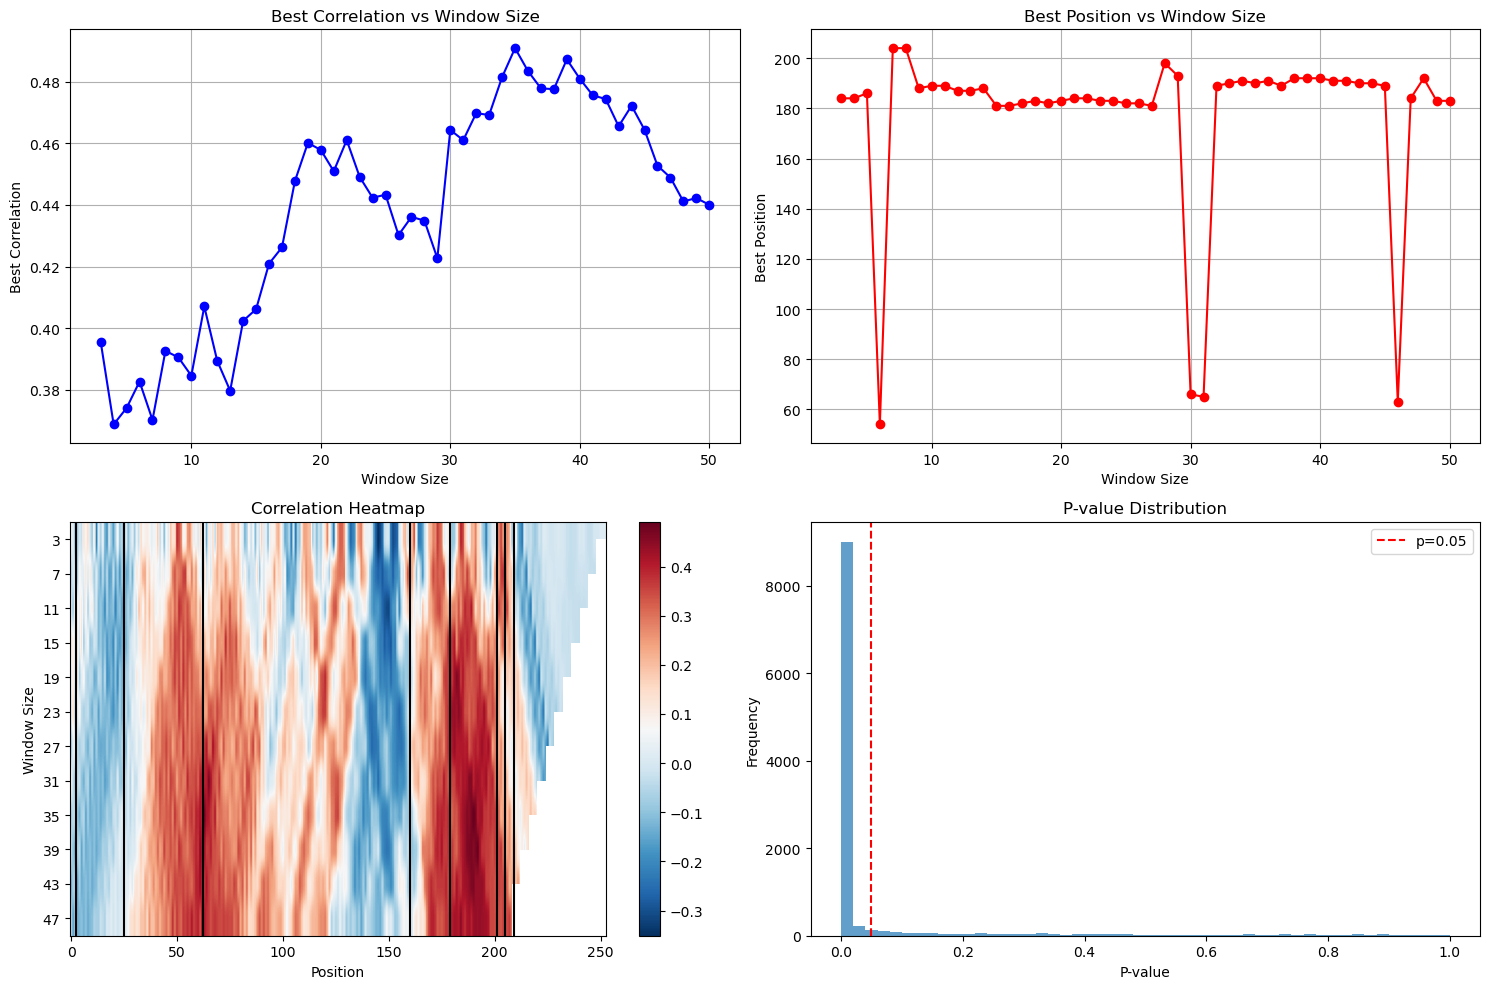

In [33]:
# # Load your data
# sasa_df = pd.read_csv('your_deltasasa_data.csv', index_col=0)  # proteins x residues
# traits = pd.read_csv('your_traits.csv', index_col=0)['trait_column']

# Initialize analyzer
analyzer = SASAWindowAnalyzer(
    sasa_df=test_df.T,
    traits=test_dataset.set_index('uid')['temp'],
    max_window_size=50,  # Adjust based on your protein lengths
    min_window_size=3
)

# Run full analysis
summary = analyzer.run_full_analysis(correlation_method='pearson')

# Get top windows
top_windows = analyzer.get_top_windows(20)
print(top_windows)

# Visualize results
analyzer.plot_results()

# Extract features for modeling
window_features = analyzer.get_window_features(10)

# Starting fresh

In [25]:
import freesasa

In [26]:
from pyrosetta import *
from pyrosetta.teaching import *

In [27]:
from Bio.Data import IUPACData
import os
os.environ['QT_QPA_PLATFORM'] = 'offscreen'

In [28]:
import numpy as np
import pandas as pd
from Bio import PDB

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
## testing out per-residue contributions
from pyrosetta import init, pose_from_pdb, get_score_function
from pyrosetta.rosetta.core.scoring import score_type_from_name
from pyrosetta.rosetta.core.simple_metrics.metrics import SasaMetric


In [30]:
from IPython.display import display, clear_output

In [31]:
import glob

## Functions

In [8]:
def residue_average_contacts(structure_file, chain_id='A', contact_cutoffs=(4.5, 1.5)):
    """
    Compute per-residue average number of atomic contacts for a given protein chain.

    Parameters
    ----------
    structure_file : str
        Path to a PDB file.
    chain_id : str, optional
        Chain identifier (default 'A').
    contact_cutoffs : tuple of float, optional
        Distance cutoffs (in Å) at which to count contacts.

    Returns
    -------
    dict
        Mapping {residue_number: average_contact_count}.
    """
    parser = PDB.PDBParser(QUIET=True)
    struct = parser.get_structure("prot", structure_file)
    
    # collect amino acid residues
    residues = [res for res in PDB.Selection.unfold_entities(struct, 'R') 
                if PDB.Polypeptide.is_aa(res, standard=True)]
    residues_present = sorted([res.id[1] for res in residues])
    residues_range = list(range(residues_present[0], residues_present[-1] + 1))
    residues_absent = set(residues_range) - set(residues_present)
    residues_missing_nbrs = residues_absent.union(
        {residues_range[0], residues_range[-1]},
        {r + 1 for r in residues_absent},
        {r - 1 for r in residues_absent}
    )

    # make a NeighborSearch for the specified chain
    model = struct[0]
    if chain_id not in model:
        raise ValueError(f"Chain {chain_id} not found in {structure_file}")
    chain = model[chain_id]
    atoms = PDB.Selection.unfold_entities(chain, 'A')
    nbr_search = PDB.NeighborSearch(atoms, bucket_size=1000)

    # compute contacts at each cutoff
    contact_counts = {cutoff: {resi: 0 if resi not in residues_absent else np.nan
                               for resi in residues_range}
                      for cutoff in contact_cutoffs}
    for cutoff in contact_cutoffs:
        for (res1, res2) in nbr_search.search_all(cutoff, level='R'):
            if res1.id[1] in contact_counts[cutoff]:
                contact_counts[cutoff][res1.id[1]] += 1
            if res2.id[1] in contact_counts[cutoff]:
                contact_counts[cutoff][res2.id[1]] += 1

    # average across cutoffs
    df = pd.DataFrame(contact_counts)
    df['average_contacts'] = df.mean(axis=1, skipna=True)

    # mask missing residues
    df.loc[list(residues_missing_nbrs), 'average_contacts'] = np.nan

    # return as dictionary
    return df['average_contacts'].to_dict()


In [6]:
init(extra_options='-mute all')

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2025 [Rosetta PyRosetta4.Release.python310.ubuntu 2025.41+release.de3cc17d509259e29147a2ed8f2a726d644e7e34 2025-10-06T16:25:46] retrieved from: http://www.pyrosetta.org


In [7]:
def get_fa_terms(pdb, terms=['fa_sol', 'fa_atr', 'fa_elec'], include_ss=True):
    
    # Load your protein structure
    pose = pose_from_pdb(pdb)
    
    # Get the default scorefunction (ref2015 or beta_nov16, etc.)
    scorefxn = get_score_function()
    
    # Score the pose
    scorefxn(pose)
    
    # Extract per-residue energies
    energies = pose.energies()
    result = dict((t, {}) for t in terms)

    # Add secondary structure dictionary if requested
    if include_ss:
        dssp = DsspMover()
        dssp.apply(pose)
        result['secondary_structure'] = {}
        sec_struct = pose.secstruct()  # returns a string of single-letter codes
        # Example: 'HHHCCCCEEE...' (H=helix, E=sheet, L/C=loop)
    
    for i in range(1, pose.total_residue() + 1):
        emap = pose.energies().residue_total_energies(i)
        # res_energy = energies.residue_total_energy(i)
        for term in terms:
            result[term][i] = emap[score_type_from_name(term)]

        if include_ss:
            result['secondary_structure'][i] = sec_struct[i - 1]
            
    clear_output(wait=True)
    return result

In [410]:


def compute_residue_sasa_and_delta(pdb_file):
    """
    Compute per-residue solvent-accessible surface area (SASA) and
    normalized ΔSASA (fractional burial) using FreeSASA.

    Parameters
    ----------
    pdb_file : str
        Path to PDB file.

    Returns
    -------
    dict
        Dictionary mapping residue number → {
            'resname': str,
            'sasa': float,
            'delta_sasa': float,
            'normalized_delta_sasa': float
        }
    """

    # Load structure and compute SASA
    structure = freesasa.Structure(pdb_file)
    result = freesasa.calc(structure)

    # Reference SASA values for fully exposed residues (Å²)
    reference_sasa = {
        'ALA': 129.0, 'ARG': 274.0, 'ASN': 195.0, 'ASP': 193.0,
        'CYS': 167.0, 'GLU': 223.0, 'GLN': 225.0, 'GLY': 104.0,
        'HIS': 224.0, 'ILE': 197.0, 'LEU': 201.0, 'LYS': 236.0,
        'MET': 224.0, 'PHE': 240.0, 'PRO': 159.0, 'SER': 155.0,
        'THR': 172.0, 'TRP': 285.0, 'TYR': 263.0, 'VAL': 174.0
    }

    # Aggregate per-residue SASA
    sasa_by_residue = {}
    for i in range(structure.nAtoms()):
        res_num = structure.residueNumber(i)
        res_name = structure.residueName(i)

        if res_num not in sasa_by_residue:
            sasa_by_residue[res_num] = {'resname': res_name, 'sasa': 0.0}

        sasa_by_residue[res_num]['sasa'] += result.atomArea(i)

    # Compute ΔSASA and normalized ΔSASA
    for res_num, res_data in sasa_by_residue.items():
        res_name = res_data['resname']
        sasa = res_data['sasa']

        if res_name in reference_sasa:
            ref_sasa = reference_sasa[res_name]
            delta = ref_sasa - sasa
            norm_delta = delta / ref_sasa if ref_sasa > 0 else None
        else:
            delta, norm_delta = None, None

        res_data['delta_sasa'] = delta
        res_data['normalized_delta_sasa'] = norm_delta

    return sasa_by_residue


In [6]:
pdbs = glob.glob('./../data/processed_structures/*.pdb')

## Testing freesasa

In [7]:
# in case the kernel dies
import freesasa
import glob

In [241]:
# Load structure and compute SASA
structure = freesasa.Structure(pdbs[0])
%time result = freesasa.calc(structure)

CPU times: user 98.9 ms, sys: 1.96 ms, total: 101 ms
Wall time: 98.9 ms


In [244]:
def get_fs_sasa(structure, result):
    # Aggregate per-residue SASA
    sasa_by_residue = {}
    for i in range(structure.nAtoms()):
        res_num = structure.residueNumber(i)
        res_name = structure.residueName(i)
    
        if res_num not in sasa_by_residue:
            sasa_by_residue[res_num] = {'resname': res_name, 'total_sasa': 0.0}
    
        sasa_by_residue[res_num]['total_sasa'] += result.atomArea(i)

    result = {}
    for key in sasa_by_residue.keys():
        result[int(key.replace(' ', ''))] = sasa_by_residue[key]
    
    return result

### Do Lee-Richards and Shrake-Rupley produce the same estimates?

In [252]:
SR_params = freesasa.Parameters({'algorithm':'ShrakeRupley', 
                                 'probe-radius':1.40,
                                 'n-points':1000})
%time result = freesasa.calc(structure, parameters=SR_params)
%time sr_sasa = get_fs_sasa(structure, result)

pd.DataFrame(sr_sasa).T.head()

CPU times: user 72.5 ms, sys: 62 µs, total: 72.6 ms
Wall time: 71.4 ms
CPU times: user 1.09 ms, sys: 0 ns, total: 1.09 ms
Wall time: 1.1 ms


,resname,total_sasa
1,MET,75.287823
2,ARG,41.924147
3,LEU,0.0
4,VAL,0.135194
5,LEU,2.898051


In [258]:
# note: passing n-threads causes the kernel to die 
LR_params = freesasa.Parameters({'algorithm':'LeeRichards',
                                'n-slices':1})
%time result = freesasa.calc(structure, parameters=LR_params)
%time lr_sasa_1 = get_fs_sasa(structure, result)
LR_params = freesasa.Parameters({'algorithm':'LeeRichards',
                                'n-slices':1000})
result = freesasa.calc(structure, parameters=LR_params)
%time lr_sasa_1000 = get_fs_sasa(structure, result)

CPU times: user 12.3 ms, sys: 0 ns, total: 12.3 ms
Wall time: 12.1 ms
CPU times: user 1.14 ms, sys: 1 µs, total: 1.14 ms
Wall time: 1.15 ms
CPU times: user 1.01 ms, sys: 0 ns, total: 1.01 ms
Wall time: 1.01 ms


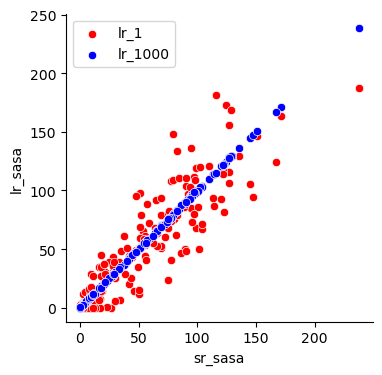

In [259]:
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(y=pd.DataFrame(lr_sasa_1).T['total_sasa'].rename('lr_sasa'),
                x=pd.DataFrame(sr_sasa).T['total_sasa'].rename('sr_sasa'), 
                color='r', label='lr_1')

sns.scatterplot(y=pd.DataFrame(lr_sasa_1000).T['total_sasa'].rename('lr_sasa'),
                x=pd.DataFrame(sr_sasa).T['total_sasa'].rename('sr_sasa'), 
                color='b', label='lr_1000')
ax.set_aspect('equal')
sns.despine()

#### Notes
For sufficient slices, yes - going with Shrake-Rupley

## Figuring out per-res total, polar, hydro

In [273]:
def get_fs_sasa_detailed(structure, result):
    # 1. Get the classifier used for the calculation
    # The standard classifier matches the default 'ProtOr' logic
    classifier = freesasa.Classifier.getStandardClassifier('protor')
    
    sasa_by_residue = {}
    
    for i in range(structure.nAtoms()):
        res_num = structure.residueNumber(i)
        res_name = structure.residueName(i)
        atom_name = structure.atomName(i)
        atom_area = result.atomArea(i)
        
        # 2. Identify atom category: polar vs apolar (non-polar)
        atom_class = classifier.classify(res_name, atom_name)
        
        if res_num not in sasa_by_residue:
            sasa_by_residue[res_num] = {
                'resname': res_name, 
                'total_sasa': 0.0, 
                'polar_sasa': 0.0, 
                'apolar_sasa': 0.0
            }
        
        # Aggregate based on classification
        sasa_by_residue[res_num]['total_sasa'] += atom_area
        
        if atom_class == freesasa.polar:
            sasa_by_residue[res_num]['polar_sasa'] += atom_area
        elif atom_class == freesasa.apolar:
            sasa_by_residue[res_num]['apolar_sasa'] += atom_area
            
    # Format keys as integers to match your original output style
    output = {int(k.strip()): v for k, v in sasa_by_residue.items()}
    return output

In [274]:
# run func
structure = freesasa.Structure(pdbs[0])
SR_params = freesasa.Parameters({'algorithm':'ShrakeRupley', 
                                 'probe-radius':1.40,
                                 'n-points':1000})
result = freesasa.calc(structure, parameters=SR_params)
sr_sasa = get_fs_sasa_detailed(structure, result)

In [275]:
pd.DataFrame(sr_sasa).T.head()

,resname,total_sasa,polar_sasa,apolar_sasa
1,MET,75.287823,19.182296,56.105527
2,ARG,41.924147,41.924147,0.0
3,LEU,0.0,0.0,0.0
4,VAL,0.135194,0.0,0.135194
5,LEU,2.898051,2.898051,0.0


## Testing sasa caculation with PyRosetta

In [276]:
# Initialize Rosetta
init()

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2025 [Rosetta PyRosetta4.Release.python310.ubuntu 2025.41+release.de3cc17d509259e29147a2ed8f2a726d644e7e34 2025-10-06T16:25:46] retrieved from: http://www.pyrosetta.org
core.init: Checking for fconfig files in pwd and ./rosetta/flags
core.init: Rosetta version: PyRosetta4.Release.python310.ubuntu r410 2025.41+release.de3cc17d50 de

In [277]:
# test codes

# total: method 1
pose = pyrosetta.pose_from_pdb(pdbs[0])
calc = pyrosetta.rosetta.core.scoring.sasa.SasaCalc()
calc.set_probe_radius(1.4)
calc.calculate(pose)
per_res = np.array(calc.get_residue_sasa())
# total
print('method 1', per_res.sum())

# total: method 2
# can use mode_code to calculate polar area
mode_code = 1
# code for calculating total w/ polar or hydro phobic option
metric = SasaMetric()
mode = pyrosetta.rosetta.core.scoring.sasa.SasaMethodHPMode(mode_code)
metric.set_sasa_metric_mode(mode_in=mode)
# total
print('method 2', metric.calculate(pose))



core.import_pose.import_pose: File './../data/processed_structures/GB_GCA_001054945.1_A_processed.pdb' automatically determined to be of type PDB from contents.
core.io.pose_from_sfr.PoseFromSFRBuilder: [ WARNING ] discarding 2 atoms at position 1 in file ./../data/processed_structures/GB_GCA_001054945.1_A_processed.pdb. Best match rsd_type:  MET:NtermProteinFull
method 1 9214.584553620405
method 2 9214.584553620403


In [311]:
def get_pr_sasa_SasaMetric_total(pdb_path):
    # Initialize pose
    pose = pyrosetta.pose_from_pdb(pdb_path)

    results = {}
    for mode_code, label in zip([1, 2, 3], ['total_sasa', 'polar_sasa', 'apolar_sasa']):

        # code for calculating total w/ polar or hydro phobic option
        metric = SasaMetric()
        mode = pyrosetta.rosetta.core.scoring.sasa.SasaMethodHPMode(mode_code)
        metric.set_sasa_metric_mode(mode_in=mode)
        results[label] = metric.calculate(pose)

    return results

In [312]:
get_pr_sasa_SasaMetric_total(pdbs[0])

core.import_pose.import_pose: File './../data/processed_structures/GB_GCA_001054945.1_A_processed.pdb' automatically determined to be of type PDB from contents.
core.io.pose_from_sfr.PoseFromSFRBuilder: [ WARNING ] discarding 2 atoms at position 1 in file ./../data/processed_structures/GB_GCA_001054945.1_A_processed.pdb. Best match rsd_type:  MET:NtermProteinFull


{'total_sasa': 9214.584553620403,
 'polar_sasa': 4315.683398425275,
 'apolar_sasa': 4898.901155195129}

In [313]:
def get_pr_sasa_SasaCalc_per_res(pose):
    '''
    Use pyrosetta to get per-residue sasas with SasaCalc obj:
    manually classify atoms to calculate "polar" and "nonpolar" (hydro)
    '''
    # 1. Setup and Calculate
    calc = pyrosetta.rosetta.core.scoring.sasa.SasaCalc()
    calc.set_probe_radius(1.4)
    calc.calculate(pose)
    per_res = np.array(calc.get_residue_sasa())
    
    # get per-atom sasa
    atom_sasa = calc.get_atom_sasa()

    polar_per_res = []
    hydro_per_res = []

    results = {}
    for i in range(1, pose.size() + 1):
        results[i] = {}
        res = pose.residue(i)
        results[i]['resname'] = res.name().split(':')[0]
        
        
        res_polar = 0.0
        res_hydro = 0.0
        # print('Total computed sasa:', per_res[i-1], f'on {res.natoms()} atoms')

        for j in range(res.natoms()):
            
            sasa_val = np.array(atom_sasa[i])[j]
            # print('this atoms sasa is:', sasa_val)
            atom_type = res.atom_type(j+1)
            
            # Rosetta logic: Polar = Donors + Acceptors + Polar Hydrogens
            if atom_type.is_donor() or atom_type.is_acceptor() or atom_type.is_polar_hydrogen():
                res_polar += np.float64(sasa_val)
            else:
                res_hydro += np.float64(sasa_val)

        results[i]['total_sasa'] = res_polar + res_hydro
        results[i]['polar_sasa'] = res_polar
        results[i]['apolar_sasa'] = res_hydro


    
    # return total, polar, hydro
    return results # np.array(polar_per_res) + np.array(hydro_per_res), np.array(polar_per_res), np.array(hydro_per_res)

In [314]:
pr_sasa = get_pr_sasa_SasaCalc_per_res(pose)

In [315]:
pd.DataFrame(pr_sasa).T.head()

,resname,total_sasa,polar_sasa,apolar_sasa
1,MET,77.461676,24.166217,53.295459
2,ARG,43.665229,43.665229,0.0
3,LEU,0.512343,0.0,0.512343
4,VAL,0.0,0.0,0.0
5,LEU,1.216301,1.216301,0.0


# Compare all methods

In [324]:
from scipy.stats import spearmanr

In [351]:
spearmanrs = []
for i, pdb in enumerate(pdbs[:100]):
    display(i)
    clear_output(wait=True)

    # run func
    structure = freesasa.Structure(pdb)
    SR_params = freesasa.Parameters({'algorithm':'ShrakeRupley', 
                                     'probe-radius':1.40,
                                     'n-points':1000})
    result = freesasa.calc(structure, parameters=SR_params)
    sr_sasa = pd.DataFrame(get_fs_sasa_detailed(structure, result)).T
    
    # with pyrosetta
    pose = pyrosetta.pose_from_pdb(pdb)
    pr_sasa = pd.DataFrame(get_pr_sasa_SasaCalc_per_res(pose)).T

    total_sp = spearmanr(pr_sasa['total_sasa'].astype(float),
                sr_sasa['total_sasa'].astype(float))
    polar_sp = spearmanr(pr_sasa['polar_sasa'].astype(float),
                    sr_sasa['polar_sasa'].astype(float))
    hydro_sp = spearmanr(pr_sasa['apolar_sasa'].astype(float),
                    sr_sasa['apolar_sasa'].astype(float))
    spearmanrs.append([total_sp[0], polar_sp[0], hydro_sp[0]])
    

core.import_pose.import_pose: File './../data/processed_structures/RS_GCF_000024025.1_A_processed.pdb' automatically determined to be of type PDB from contents.
core.io.pose_from_sfr.PoseFromSFRBuilder: [ WARNING ] discarding 2 atoms at position 1 in file ./../data/processed_structures/RS_GCF_000024025.1_A_processed.pdb. Best match rsd_type:  MET:NtermProteinFull
core.conformation.Conformation: [ WARNING ] missing heavyatom:  OXT on residue ARG:CtermProteinFull 224


In [352]:
pr_sasa.head()

,resname,total_sasa,polar_sasa,apolar_sasa
1,MET,39.466169,26.400238,13.06593
2,ARG,34.744898,17.313472,17.431425
3,ILE,0.0,0.0,0.0
4,VAL,0.0,0.0,0.0
5,LEU,1.216301,1.216301,0.0


In [353]:
sr_sasa.head()

,resname,total_sasa,polar_sasa,apolar_sasa
1,MET,34.423411,20.904007,13.519404
2,ARG,31.445395,19.62654,11.818855
3,ILE,0.0,0.0,0.0
4,VAL,0.0,0.0,0.0
5,LEU,2.433649,2.298455,0.135194


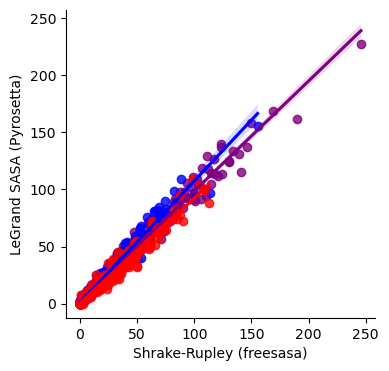

In [354]:

fig, ax = plt.subplots(figsize=(4, 4))
sns.regplot(x=pr_sasa['total_sasa'].astype(float),
                y=sr_sasa['total_sasa'].astype(float), color='purple', label='total')
sns.regplot(x=pr_sasa['polar_sasa'].astype(float),
                y=sr_sasa['polar_sasa'].astype(float), color='b', label='polar')
sns.regplot(x=pr_sasa['apolar_sasa'].astype(float),
                y=sr_sasa['apolar_sasa'].astype(float), color='r', label='hydro')

ax.set_xlabel('Shrake-Rupley (freesasa)')
ax.set_ylabel('LeGrand SASA (Pyrosetta)')
sns.despine()
ax.set_aspect('equal')

In [357]:
pd.DataFrame(spearmanrs).mean()

0    0.990394
1    0.980662
2    0.981657
dtype: float64

## Notes:
Estimates of per-residue hydrophobic (apolar), polar and total sasa are extremely correlated across the Shrake-Rupley method used by freesasa and the LeGrand estimation used by PyRosetta

## Final test: do the numbers match original Rosetta / PDB estimates?

In [384]:
pdb

'./../data/processed_structures/RS_GCF_000024025.1_A_processed.pdb'

In [385]:
pdb = './../data/processed_structures/RS_GCF_000024025.1_A_processed.pdb'

# run func
structure = freesasa.Structure(pdb)
SR_params = freesasa.Parameters({'algorithm':'ShrakeRupley', 
                                 'probe-radius':1.40,
                                 'n-points':1000})
result = freesasa.calc(structure, parameters=SR_params)
sr_sasa = pd.DataFrame(get_fs_sasa_detailed(structure, result)).T

# with pyrosetta
pose = pyrosetta.pose_from_pdb(pdb)
pr_sasa = pd.DataFrame(get_pr_sasa_SasaCalc_per_res(pose)).T

core.import_pose.import_pose: File './../data/processed_structures/RS_GCF_000024025.1_A_processed.pdb' automatically determined to be of type PDB from contents.
core.io.pose_from_sfr.PoseFromSFRBuilder: [ WARNING ] discarding 2 atoms at position 1 in file ./../data/processed_structures/RS_GCF_000024025.1_A_processed.pdb. Best match rsd_type:  MET:NtermProteinFull
core.conformation.Conformation: [ WARNING ] missing heavyatom:  OXT on residue ARG:CtermProteinFull 224


In [406]:
sr_sasa.head()

,resname,total_sasa,polar_sasa,apolar_sasa
1,MET,34.423411,20.904007,13.519404
2,ARG,31.445395,19.62654,11.818855
3,ILE,0.0,0.0,0.0
4,VAL,0.0,0.0,0.0
5,LEU,2.433649,2.298455,0.135194


In [386]:
structural_metrics = pd.read_csv('./../data/metric_tables/20240327_metrics_df_filtered.tsv.gz',
           sep='\t', compression='gzip')

In [387]:
print('freesasa (Shrake-Rupley) stats:')
print(sr_sasa.sum())
print()
print(sr_sasa.iloc[:, 1:].mean())

freesasa (Shrake-Rupley) stats:
resname        METARGILEVALLEUVALGLYPROPROGLYALAGLYLYSGLYTHRG...
total_sasa                                          10730.250266
polar_sasa                                           4917.155281
apolar_sasa                                          5813.094984
dtype: object

total_sasa     47.902903
polar_sasa     21.951586
apolar_sasa    25.951317
dtype: object


In [388]:
print('PyRosetta (LeGrand procedure) stats:')
print(pr_sasa.sum())
print()
print(pr_sasa.iloc[:, 1:].mean())

PyRosetta (LeGrand procedure) stats:
resname        METARGILEVALLEUVALGLYPROPROGLYALAGLYLYSGLYTHRG...
total_sasa                                          10596.566469
polar_sasa                                           4427.780854
apolar_sasa                                          6168.785615
dtype: object

total_sasa       47.3061
polar_sasa     19.766879
apolar_sasa    27.539221
dtype: object


In [389]:
structural_metrics[structural_metrics['uid'].eq('RS_GCF_000024025.1')][['SASA', 'polar_sasa', 'nonpolar_sasa', 'sasa']]

,SASA,polar_sasa,nonpolar_sasa,sasa
173,47.863542,4428.575,6167.991,10596.566


#### Notes:
yes: SR / pyrosetta estimates do not match, but pyrosetta matches rosetta and SR matches Bio.PDB.ShrakeRupley method

## Are per-residue statistics correlated?

In [390]:
bio_per_res = pd.read_csv('./../data/metric_tables/20240524_full_metrics.tsv.gz', sep='\t', compression='gzip')

In [391]:
bio_per_res[bio_per_res.uid.eq('RS_GCF_000024025.1')]

,Position,Contacts at 4.5 Å,SASA,uid
40161,1,13,38.986034,RS_GCF_000024025.1
40162,2,15,28.506560,RS_GCF_000024025.1
40163,3,16,0.000000,RS_GCF_000024025.1
40164,4,16,0.000000,RS_GCF_000024025.1
40165,5,15,0.750021,RS_GCF_000024025.1
...,...,...,...,...
40380,220,16,0.000000,RS_GCF_000024025.1
40381,221,11,72.036267,RS_GCF_000024025.1
40382,222,7,96.224321,RS_GCF_000024025.1
40383,223,9,44.166354,RS_GCF_000024025.1


In [393]:
bio_per_res[bio_per_res.uid.eq('RS_GCF_000024025.1')]['SASA'].mean()

47.86354204168821

In [395]:
sr_sasa['total_sasa']

1       34.423411
2       31.445395
3             0.0
4             0.0
5        2.433649
          ...    
220           0.0
221     72.388171
222     92.753536
223     44.421222
224    161.799413
Name: total_sasa, Length: 224, dtype: object

In [398]:
bio_per_res[bio_per_res.uid.eq('RS_GCF_000024025.1')].set_index('Position')['SASA']

Position
1       38.986034
2       28.506560
3        0.000000
4        0.000000
5        0.750021
          ...    
220      0.000000
221     72.036267
222     96.224321
223     44.166354
224    167.994413
Name: SASA, Length: 224, dtype: float64

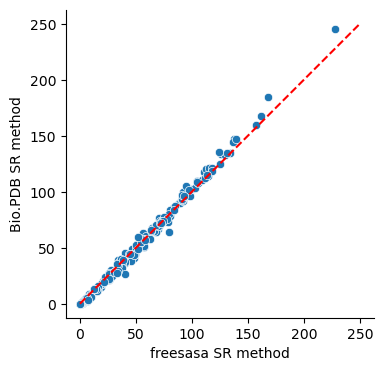

In [405]:
fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(x=sr_sasa['total_sasa'],
                y=bio_per_res[bio_per_res.uid.eq('RS_GCF_000024025.1')].set_index('Position')['SASA'])
ax.set_ylabel('Bio.PDB SR method')
ax.set_xlabel('freesasa SR method')
plt.plot((0, 250), (0, 250), color='r', linestyle='--')
ax.set_aspect('equal')
sns.despine()

### Summary
1. The LeGrand procedure and freesasa are generally very correlated (SpearmanR > 0.98)
1. freesasa is a good estimator of SASA calculation by Bio.PDB, but can separate into polar and nonpolar
2. Using PyRosetta to calculate per-residue total, polar, and apolar sasa produces the same estimates as with Rosetta

# Buried (delta) SASA
will go forward with freesasa method, but thinking about comparing to PyRosetta

In [ ]:
Tien_ASAs = {'Alanine',: 121.0,
            'Arginine',: 265.0,
            'Asparagine',: 187.0,
            'Aspartate',: 187.0,
            'Cysteine',: 148.0,
            'Glutamate',: 214.0,
            'Glutamine',: 214.0,
            'Glycine',: 97.0 ,
            'Histidine',: 216.0,
            'Isoleucine',: 195.0,
            'Leucine',: 191.0,
            'Lysine',: 230.0,
            'Methionine',: 203.0,
            'Phenylalanine',: 228.0,
            'Proline',: 154.0,
            'Serine',: 143.0,
            'Threonine',: 163.0,
            'Tryptophan',: 264.0,
            'Tyrosine',: 255.0,
            'Valine',: 165.0}

## PyRosetta-based Buried SASA

# Initialize PyRosetta (actual calculation)

In [407]:
pdbs = glob.glob('./../data/processed_structures/*.pdb')

In [408]:
# Initialize Rosetta
init()

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2025 [Rosetta PyRosetta4.Release.python310.ubuntu 2025.41+release.de3cc17d509259e29147a2ed8f2a726d644e7e34 2025-10-06T16:25:46] retrieved from: http://www.pyrosetta.org
core.init: Checking for fconfig files in pwd and ./rosetta/flags
core.init: Rosetta version: PyRosetta4.Release.python310.ubuntu r410 2025.41+release.de3cc17d50 de

## Compute Surface Areas

In [423]:
# freesasa and pyrosetta-based 
all_sasa_dfs = []
for i, _pdb in enumerate(pdbs):
    display(i)
    # run func
    structure = freesasa.Structure(_pdb)
    SR_params = freesasa.Parameters({'algorithm':'ShrakeRupley', 
                                     'probe-radius':1.40,
                                     'n-points':1000})
    result = freesasa.calc(structure, parameters=SR_params)
    sr_sasa = pd.DataFrame(get_fs_sasa_detailed(structure, result)).T
    
    # with pyrosetta
    pose = pyrosetta.pose_from_pdb(_pdb)
    pr_sasa = pd.DataFrame(get_pr_sasa_SasaCalc_per_res(pose)).T

    sasa_df = pd.merge(sr_sasa, pr_sasa, left_index=True, right_index=True).assign(pdb=_pdb)
    
    all_sasa_dfs.append(sasa_df)
    clear_output(wait=True)

9340

core.import_pose.import_pose: File './../data/processed_structures/RS_GCF_902813185.1_A_processed.pdb' automatically determined to be of type PDB from contents.
core.io.pose_from_sfr.PoseFromSFRBuilder: [ WARNING ] discarding 2 atoms at position 1 in file ./../data/processed_structures/RS_GCF_902813185.1_A_processed.pdb. Best match rsd_type:  MET:NtermProteinFull
core.conformation.Conformation: [ WARNING ] missing heavyatom:  OXT on residue SER:CtermProteinFull 221


In [424]:
all_sasa_data = pd.concat(all_sasa_dfs)

In [425]:
all_sasa_data.head()

,resname_x,total_sasa_x,polar_sasa_x,apolar_sasa_x,resname_y,total_sasa_y,polar_sasa_y,apolar_sasa_y,pdb
1,MET,75.287823,19.182296,56.105527,MET,77.461676,24.166217,53.295459,./../data/processed_structures/GB_GCA_00105494...
2,ARG,41.924147,41.924147,0.0,ARG,43.665229,43.665229,0.0,./../data/processed_structures/GB_GCA_00105494...
3,LEU,0.0,0.0,0.0,LEU,0.512343,0.0,0.512343,./../data/processed_structures/GB_GCA_00105494...
4,VAL,0.135194,0.0,0.135194,VAL,0.0,0.0,0.0,./../data/processed_structures/GB_GCA_00105494...
5,LEU,2.898051,2.898051,0.0,LEU,1.216301,1.216301,0.0,./../data/processed_structures/GB_GCA_00105494...


In [436]:
# rename colummns
all_sasa_data = all_sasa_data.drop('resname_y', axis=1).rename(columns=dict((c, c.replace('_x', '_fs').replace('_y', '_pr')) if not 'resname' in c else (c, 'resname') for c in all_sasa_data.columns))

In [440]:
# add a uid column
all_sasa_data['uid'] = all_sasa_data['pdb'].apply(lambda x: x.split('/')[-1].split('_A')[0])

In [441]:
all_sasa_data.head()

,resname,total_sasa_fs,polar_sasa_fs,apolar_sasa_fs,total_sasa_pr,polar_sasa_pr,apolar_sasa_pr,pdb,uid
1,MET,75.287823,19.182296,56.105527,77.461676,24.166217,53.295459,./../data/processed_structures/GB_GCA_00105494...,GB_GCA_001054945.1
2,ARG,41.924147,41.924147,0.0,43.665229,43.665229,0.0,./../data/processed_structures/GB_GCA_00105494...,GB_GCA_001054945.1
3,LEU,0.0,0.0,0.0,0.512343,0.0,0.512343,./../data/processed_structures/GB_GCA_00105494...,GB_GCA_001054945.1
4,VAL,0.135194,0.0,0.135194,0.0,0.0,0.0,./../data/processed_structures/GB_GCA_00105494...,GB_GCA_001054945.1
5,LEU,2.898051,2.898051,0.0,1.216301,1.216301,0.0,./../data/processed_structures/GB_GCA_00105494...,GB_GCA_001054945.1


In [442]:
# save
all_sasa_data.to_csv('./../data/metric_tables/20260513_sasa_metrics.tsv.gz', sep='\t', compression='gzip')

## parse per-residue Buried SA from Rosetta

In [443]:
rosetta_logs = glob.glob('./../data/rosetta_out/*_A_processed_rosetta.log')
print(f'Found {len(rosetta_logs)} logs')

Found 9341 logs


In [492]:
def parse_bsa(logfile: str) -> pd.DataFrame:
    '''
    Function to take a rosetta log file and extract buried surface areas
    as a dataframe
    logfile: str: location of log
    return pd.dataframe with cols: 
        resname (MET, etc.), total bsa, apolar bsa, logfile str, uid
    '''
    
    with open(logfile, 'r') as handle:
        lines = [l.strip() for l in handle.readlines()]
        
    bsas = []
    sasa_labels = ['calc_bsa_total', 'calc_bsa_apolar']
    for label in sasa_labels:
        header = f'============Begin report for {label}=================='
        footer = f'============End report for {label}=================='
    
        # get loc of header
        for header_loc, l in enumerate(lines):
            if header in l:
                break
        
        # get loc of footer
        for footer_loc, l in enumerate(lines):
            if footer in l:
                break
    
        # get lines correspond to this label
        parsed_bsa_raw = [l.split('REPORT: ')[-1] for l in lines[header_loc+1:footer_loc-2]] 
        # extract tab-delimited data from lines
        bsa = pd.Series(dict((l.split('\t')[0], float(l.split('\t')[1])) for i, l in enumerate(parsed_bsa_raw) if i != 0)).reset_index()
    
        # some formatting
        bsa.index = [i + 1 for i in bsa.index]
        bsa['resname'] = bsa['index'].apply(lambda x: x[:3])
        bsa = bsa.rename(columns={0:label.replace('calc_', '')}).drop('index', axis=1)
        bsas.append(bsa)
    # merge two bsa files on residue loc
    both_bsa = pd.merge(bsas[0], 
                        bsas[1].drop('resname', axis=1), 
                        left_index=True, right_index=True)
    uid = logfile.split('/')[-1].split('_A_processed_rosetta')[0]
    both_bsa = both_bsa.assign(file=log).assign(uid=uid)
    return both_bsa


In [500]:
all_rosetta_bsa = []
for i, log in enumerate(rosetta_logs):
    if i % 100 == 0:
        display(i)
    all_rosetta_bsa.append(parse_bsa(log))  
    clear_output(wait=True)

9300

In [501]:
all_rosetta_bsa_df = pd.concat(all_rosetta_bsa)

In [503]:
all_rosetta_bsa_df.to_csv('./../data/metric_tables/20260513_rosetta_bsa_metrics.tsv.gz', 
                          sep='\t', compression='gzip')

## Compute additional metrics

In [411]:
all_protein_data = []
for i, _pdb in enumerate(pdbs[:1]):
    print(i)
    sasa_df = pd.DataFrame(compute_residue_sasa_and_delta(_pdb)).T
    sasa_df.index = [int(i.lstrip(' ').rstrip(' ')) for i in sasa_df.index]
    # fa_term_df = pd.DataFrame(get_fa_terms(_pdb))
    
    contact_range = 4.5
    contacts = pd.Series(residue_average_contacts(_pdb, contact_cutoffs=(contact_range,)), name=f'contacts_at_{contact_range}')
    pdb_df = pd.concat([sasa_df, contacts], axis=1).assign(file=_pdb).rename_axis(index='loc')
    all_protein_data.append(pdb_df)

0


NameError: name 'residue_average_contacts' is not defined

In [412]:
sasa_df

,resname,sasa,delta_sasa,normalized_delta_sasa
1,MET,75.315752,148.684248,0.663769
2,ARG,41.959943,232.040057,0.846862
3,LEU,0.0,201.0,1.0
4,VAL,0.125247,173.874753,0.99928
5,LEU,3.253464,197.746536,0.983814
...,...,...,...,...
177,ASP,75.552396,117.447604,0.608537
178,ALA,17.18647,111.81353,0.866772
179,LEU,21.711449,179.288551,0.891983
180,ASP,127.748046,65.251954,0.338093


In [578]:
plotdf = pd.concat(all_protein_data, axis=0).reset_index()

In [579]:
plotdf.head()

,loc,resname,sasa,delta_sasa,normalized_delta_sasa,fa_sol,fa_atr,fa_elec,secondary_structure,contacts_at_4.5,file
0,1,MET,75.315752,148.684248,0.663769,2.886560,-6.134512,-3.269996,L,NaN,./../data/processed_structures/GB_GCA_00105494...
1,2,ARG,41.959943,232.040057,0.846862,7.630707,-9.452707,-6.076714,E,14.0,./../data/processed_structures/GB_GCA_00105494...
2,3,LEU,0.0,201.0,1.0,1.217929,-8.927249,-2.658222,E,16.0,./../data/processed_structures/GB_GCA_00105494...
3,4,VAL,0.125247,173.874753,0.99928,0.905438,-7.462143,-1.721541,E,16.0,./../data/processed_structures/GB_GCA_00105494...
4,5,LEU,3.253464,197.746536,0.983814,0.664696,-8.006336,-1.481625,E,16.0,./../data/processed_structures/GB_GCA_00105494...


In [336]:
# %store plotdf

Stored 'plotdf' (DataFrame)


In [580]:
plotdf['uid'] = plotdf['file'].apply(lambda x: x.split('/')[-1].split('_A')[0])
plotdf = plotdf.drop('file', axis=1).set_index(['uid', 'loc'])

In [581]:
plotdf.to_csv('./../data/metric_tables/20251012_per_residue_data.tsv.gz',
             sep='\t', compression='gzip')

In [11]:
plotdf = pd.read_csv('./../data/metric_tables/20251012_per_residue_data.tsv.gz',
                    sep='\t', compression='gzip', index_col=[0,1])

## Try to align residues with alignment residues

In [13]:
def check_mapping(msa_fa, mapping, _id, actual_residues, verbose=False, check=True):
    aln_seq = get_seq_from_msa(msa_fa, _id)
    for key, item in mapping.items():
        # account for trailing gaps
        if item is not None:
            o_res, a_res = actual_residues[key], aln_seq[item]
            if verbose:
                print(o_res, a_res)
            if check:
                assert a_res in ['-', o_res],  f'{a_res} to {o_res} @ {key}'

    return True

def get_seq_from_msa(msa_fa, seq_id):
    rec = None
    for r in SeqIO.parse(msa_fa, "fasta"):
        if r.id == seq_id:
            rec = r
            break
    if rec is None:
        raise ValueError(f"Protein {seq_id} not found in MSA")

    aln_seq = str(rec.seq)
    return aln_seq

In [14]:
def map_residues_to_alignment_columns(msa_fasta, protein_id, orig_res):
    """
    Given an MSA fasta and a protein identifier inside it,
    map original residue positions to alignment column indices.

    Parameters
    ----------
    msa_fasta : str
        path to a FoldMason MSA FASTA (AA alignment).
    protein_id : str
        The seq record ID in the MSA file corresponding to this protein.
    orig_res_nums : list[int]
        List of original residue numbers (in order) for that protein.

    Returns
    -------
    dict
        Mapping: original residue number → alignment column index (1-based)
        (or None if gap / not aligned).
    """
    aln_seq = get_seq_from_msa(msa_fasta, protein_id)
    # iterate through alignment sequence, track mapping of ungapped-seq index → alignment column
    mapping = {}
    if len(np.unique([s for s in aln_seq])) < 2:
        return mapping
        
    # start at first maintained location in sequence
    first_aln_res = [s for s in aln_seq if s != '-'][0]
    for seq_idx in orig_res.index:
        if orig_res.loc[seq_idx] == first_aln_res:
            break
    

    # seq_idx = index in original (ungapped) sequence
    for aln_col, aa in enumerate(aln_seq, start=0):

        if aa != "-":

            mapping[seq_idx] = aln_col

            seq_idx += 1

            if seq_idx >= orig_res.index.max():
                break
            
        # if we've reached the end of the alignment
        if aln_col+1 > len(aln_seq)-1:
            break

        # if the column was deleted, move until a match is found   
        if (aln_seq[aln_col+1] != '-'):
            while (aln_seq[aln_col+1] != orig_res.loc[seq_idx]):
                seq_idx += 1
        # print(seq_idx)
    
    # For any original residues not matched (e.g. trailing gaps), map to None
    for res in orig_res.index:
        if res not in mapping:
            mapping[res] = None

    return mapping





In [22]:
with open('./../data/high_qual_alignments/backbone.afa', 'r') as handle:
    records = [r for r in SeqIO.parse(handle, format='fasta')]

In [23]:
msa_id_to_uid = dict((r.id.split('|')[1], r.id) for r in records)

In [24]:
len(list(enumerate(list(filtered['uid'].unique()))))

8532

In [26]:
idx = pd.IndexSlice

In [27]:
_ids, _seqs = [], []
for i, _id in list(enumerate(list(filtered['uid'].unique()))):
    # check every 5 and update progress
    if i % 10 == 0:
        display(i)
        
    # original locations to residues, for checking
    loc2res = plotdf.loc[idx[_id, :], 'resname'].dropna().map(lambda x: IUPACData.protein_letters_3to1[x.strip().title()]).droplevel(0)
    _ids.append(pd.Series(msa_id_to_uid).loc[_id].replace('|adk|', '|pdb|'))
    _seqs.append(''.join(list(loc2res.values)))
    clear_output(wait=True)

8530

In [34]:
with open('./../data/high_qual_alignments/pdb_seqs.faa', 'w') as handle:
    for _id, _seq in zip(_ids, _seqs):
        handle.write(f'>{_id}\n{_seq}\n')

# now do mapping for pdb-based msa

In [35]:
with open('./../data/high_qual_alignments/test_pdb_backbone.afa', 'r') as handle:
    records = [r for r in SeqIO.parse(handle, format='fasta')]

In [36]:
len(records)

17064

In [37]:
msa_id_to_uid = dict((r.id.split('|')[1], r.id) for r in records if '|pdb|' in r.id)

In [38]:
len(list(enumerate(list(filtered['uid'].unique()))))

8532

In [39]:
msa_id_to_uid

{'GB_GCA_000376885.1': 'AQXR01000011.1_67|GB_GCA_000376885.1|pdb|temp=37.0|bitscore=178.2',
 'GB_GCA_000016765.1': 'CP000699.1_1354|GB_GCA_000016765.1|pdb|temp=30.0|bitscore=175.3',
 'GB_GCA_000242235.1': 'JH590862.1_220|GB_GCA_000242235.1|pdb|temp=37.0|bitscore=192.2',
 'GB_GCA_000283575.1': 'AP012044.1_910|GB_GCA_000283575.1|pdb|temp=30.0|bitscore=168.7',
 'GB_GCA_001054945.1': 'JVKJ01000005.1_776|GB_GCA_001054945.1|pdb|temp=37.0|bitscore=192.9',
 'GB_GCA_000411155.1': 'KE150266.1_745|GB_GCA_000411155.1|pdb|temp=37.0|bitscore=164.5',
 'GB_GCA_001187505.1': 'CP012150.1_6387|GB_GCA_001187505.1|pdb|temp=37.0|bitscore=179.2',
 'GB_GCA_001749745.1': 'JWTM01000507.1_2|GB_GCA_001749745.1|pdb|temp=35.0|bitscore=176.1',
 'GB_GCA_000717275.1': 'JNYV01000004.1_381|GB_GCA_000717275.1|pdb|temp=28.0|bitscore=181.4',
 'GB_GCA_001184205.1': 'LBMP01000009.1_70|GB_GCA_001184205.1|pdb|temp=30.0|bitscore=199.8',
 'GB_GCA_000423665.1': 'AUIK01000001.1_79|GB_GCA_000423665.1|pdb|temp=28.0|bitscore=174.9',


In [40]:
# assign an "aligned res" column
# msa = './../data/result.fasta_aa_nogap.fa'
msa = './../data/high_qual_alignments/test_pdb_backbone.afa'
idx = pd.IndexSlice

for i, _id in list(enumerate(list(filtered['uid'].unique()))):
    # check every 5 and update progress
    if i % 10 == 0:
        display(i)
        
    # original locations to residues, for checking
    loc2res = plotdf.loc[idx[_id, :], 'resname'].dropna().map(lambda x: IUPACData.protein_letters_3to1[x.strip().title()]).droplevel(0)
    # og res to alignment res
    mapping = map_residues_to_alignment_columns(msa, msa_id_to_uid[_id], loc2res)
    # mapping = map_residues_to_alignment_columns(msa, f'{_id}_A_processed', loc2res)
        
    check_mapping(msa, mapping, msa_id_to_uid[_id], loc2res.to_dict())    
    # # check_mapping(msa, mapping, f'{_id}_A_processed', loc2res.to_dict())
        
    # assign new column
    plotdf.loc[idx[_id, :], 'aln_res'] = plotdf.loc[idx[_id, :], :].index.get_level_values(1).map(mapping)
    clear_output(wait=True)

8530

In [221]:
# original_res
_id

'GB_GCA_000411155.1'

In [220]:
# aln_seq
str([r.seq for r in records if r.id == msa_id_to_uid[_id]][0])

'MAILILGAPGAGKGTQAKRIAEVLQIPAISTGAIFRQNMKDRTELGQKAQSYMDAGEFVPDSVTNPMVKARLSAPDVASGFLLDGYPRTIDQAFYLRATGRELDLVLEIAVELDEVVQRLLKRAEIEGRADDTEPVIRRRLEVYKEQTEPMVTYYADQDKLVQVDGIGTVDEVWERIRQVLT'

In [185]:
pd.Series(msa_id_to_uid).loc[_id]

'KE150266.1_745|GB_GCA_000411155.1|adk|temp=37.0|bitscore=164.5'

In [586]:
# print(i)

# check_mapping(msa, mapping, f'{_id}_A_processed', loc2res.to_dict(), verbose=True, check=False)

# get_seq_from_msa(msa, f'{_id}_A_processed')

# ''.join(list(loc2res.values))

In [41]:
plotdf.to_csv('./../data/metric_tables/20251012_per_residue_data.tsv.gz',
             sep='\t', compression='gzip')

## plotting (jesus christ finally)

In [238]:
import matplotlib as mpl
from matplotlib.collections import LineCollection

In [28]:
plotdf = pd.read_csv('./../data/metric_tables/20251012_per_residue_data.tsv.gz',
             sep='\t', compression='gzip', index_col=[0,1])

In [239]:
plotdf.head()

resname       sasa  delta_sasa  normalized_delta_sasa  \
uid                loc                                                         
GB_GCA_001054945.1 1       MET  75.315752  148.684248               0.663769   
                   2       ARG  41.959943  232.040057               0.846862   
                   3       LEU   0.000000  201.000000               1.000000   
                   4       VAL   0.125247  173.874753               0.999280   
                   5       LEU   3.253464  197.746536               0.983814   

                          fa_sol    fa_atr   fa_elec secondary_structure  \
uid                loc                                                     
GB_GCA_001054945.1 1    2.886560 -6.134512 -3.269996                   L   
                   2    7.630707 -9.452707 -6.076714                   E   
                   3    1.217929 -8.927249 -2.658222                   E   
                   4    0.905438 -7.462143 -1.721541                   E   
                   5    0.664696 -8.006336 -1.481625                   E   

                        contacts_at_4.5  aln_res  
uid                loc                            
GB_GCA_001054945.1 1                NaN      0.0  
                   2               14.0      1.0  
                   3               16.0      2.0  
                   4               16.0      3.0  
                   5               16.0      4.0

In [240]:
plotdf['temp'] = plotdf.index.get_level_values(0).map(filtered.set_index('uid')['temp'].to_dict())

In [241]:
plotdf.head()

resname       sasa  delta_sasa  normalized_delta_sasa  \
uid                loc                                                         
GB_GCA_001054945.1 1       MET  75.315752  148.684248               0.663769   
                   2       ARG  41.959943  232.040057               0.846862   
                   3       LEU   0.000000  201.000000               1.000000   
                   4       VAL   0.125247  173.874753               0.999280   
                   5       LEU   3.253464  197.746536               0.983814   

                          fa_sol    fa_atr   fa_elec secondary_structure  \
uid                loc                                                     
GB_GCA_001054945.1 1    2.886560 -6.134512 -3.269996                   L   
                   2    7.630707 -9.452707 -6.076714                   E   
                   3    1.217929 -8.927249 -2.658222                   E   
                   4    0.905438 -7.462143 -1.721541                   E   
                   5    0.664696 -8.006336 -1.481625                   E   

                        contacts_at_4.5  aln_res  temp  
uid                loc                                  
GB_GCA_001054945.1 1                NaN      0.0  37.0  
                   2               14.0      1.0  37.0  
                   3               16.0      2.0  37.0  
                   4               16.0      3.0  37.0  
                   5               16.0      4.0  37.0

In [244]:
conserved_residues = (plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()) > 0.90)

In [245]:
therm_data = plotdf[plotdf['temp'] > 40]
meso_data = plotdf[(plotdf['temp'] < 40) & (plotdf['temp'] > 20)]
psychro_data = plotdf[(plotdf['temp'] < 20)]

In [246]:
drop_cols = ['uid', 'resname', 'loc', 'temp', 'secondary_structure', 'delta_sasa']
single_plot_data1 = therm_data.reset_index().dropna(axis=0).drop(drop_cols, axis=1).groupby('aln_res').mean()
single_plot_data2 = meso_data.reset_index().dropna(axis=0).drop(drop_cols, axis=1).groupby('aln_res').mean()

In [247]:
# bcs = pd.read_csv('./../class_project/data/csubst_analysis/csubst_newhot/branch_convergent_sites.tsv', sep='\t', index_col=0)
# bcs[bcs.site.eq(62)]
contrast_data = single_plot_data1 - single_plot_data2

contrast_data = contrast_data.reset_index()

# contrast_data = contrast_data.mask(~contrast_data['aln_res'].isin(conserved_residues[conserved_residues].index))

In [248]:
# ---- Aggregate per aligned residue ----
grouped = plotdf.groupby('aln_res').agg({
    'delta_sasa': 'mean',
    'secondary_structure': lambda x: x.value_counts().idxmax()  # modal SS
}).reset_index()

# Map secondary structure to colors
ss_color_map = {'H': '#d7191c',  # Helix - red
                'E': '#2c7bb6',  # Sheet - blue
                'C': '#fdae61'}  # Coil/other - orange

grouped['ss_color'] = grouped['secondary_structure'].map(ss_color_map).fillna('gray')

In [249]:
grouped.head()

,aln_res,delta_sasa,secondary_structure,ss_color
0,0.0,156.868921,L,gray
1,1.0,206.893740,E,#2c7bb6
2,2.0,197.212840,E,#2c7bb6
3,3.0,189.469742,E,#2c7bb6
4,4.0,201.310940,E,#2c7bb6


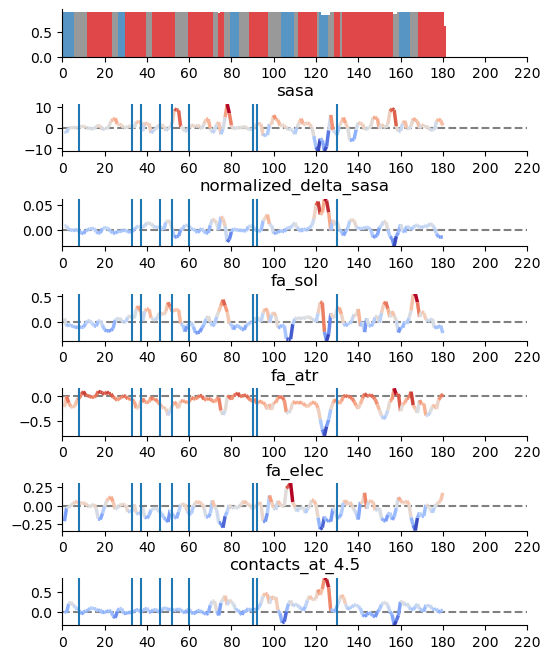

In [251]:
fig = plt.figure(figsize=(6,8))

 #.stack().reset_index().rename(columns={'level_1':'stat', 0:'value'})

ax1 = fig.add_subplot(7,1,1)
ax1.bar(grouped['aln_res'], (plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique())).sort_index(),
       color=grouped['ss_color'], width=1, alpha=0.8, zorder=1)

i = 2
for col in contrast_data.drop('aln_res', axis=1).columns:
    ax = fig.add_subplot(7,1,i, sharex=ax1)
    
    ax.axhline(0, color='gray', linestyle='--', zorder=0)
            
    x = contrast_data['aln_res']
    y = contrast_data[col]
    y_smooth = y.rolling(window=3, center=True).mean()
    
    # Plotting
    # Build segments for LineCollection
    points = np.array([x, y_smooth]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Normalize and color map
    # norm = mpl.colors.TwoSlopeNorm(vcenter=0, vmin=y_smooth.min(), vmax=y_smooth.max())
    norm = mpl.colors.Normalize(vmin=y_smooth.min(), vmax=y_smooth.max())
    lc = LineCollection(
        segments,
        cmap='coolwarm',
        norm=norm,
        linewidth=2.5
    )
    lc.set_array(y_smooth.values)
    ax.add_collection(lc)
    
    # plt.scatter(x, y_smooth, label='Smoothed Curve (Spline)', c=colors, s=3)    
    sns.despine()
    ax.set_title(col)
    ax.set_xlabel('')
    # ax.set_ylabel(col, rotation=0, )
    for col in [46, 130, 8, 52, 60, 37, 92, 0, 33, 90]:
        ax.axvline(col)
    

        # Adjust limits
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y_smooth.min(), y_smooth.max())
    ax.set_xticks(range(0, 240, 20))
    
    if i != 7:
        
        pass


    i += 1
    
fig.subplots_adjust(hspace=1)

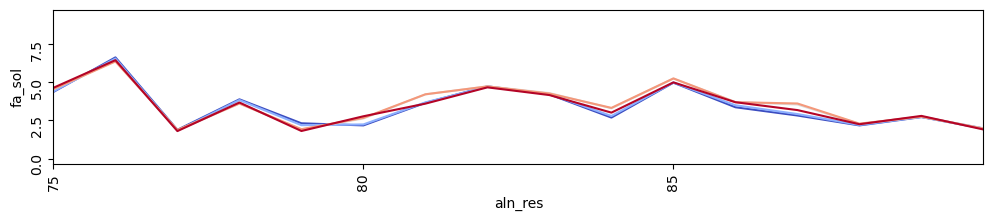

In [179]:
# visualization of how a statistic changes at different temperatures
fig, ax = plt.subplots(figsize=(12, 2))
mintemp, maxtemp = 20, 40
norm = mpl.colors.Normalize(mintemp, maxtemp)
for temp in np.linspace(mintemp, maxtemp, 5):
    
    plot_data= plotdf[(plotdf['temp'] > temp) & (plotdf['temp'] < (temp+10))].reset_index().dropna(axis=0).drop(drop_cols, axis=1).groupby('aln_res').mean()
    sns.lineplot(data=plot_data, 
                 x='aln_res', 
                 y=plot_data['fa_sol'], # - plotdf.groupby('aln_res')['fa_atr'].mean(), 
                 c=mpl.colormaps['coolwarm'](norm(temp)))
left, right = 75, 90
ax.set_xlim(left, right)
xticks = ax.set_xticks(range(left, right, 5))
plt.tick_params(rotation=90)

In [42]:
import numpy as np
from scipy import stats
from ete3 import Tree
from typing import Dict, Tuple, List
import pandas as pd

In [43]:
from scipy.stats import spearmanr

In [60]:
# from ete3 import 
from ete3 import Tree, RectFace, TextFace, CircleFace, faces, TreeStyle, AttrFace, NodeStyle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


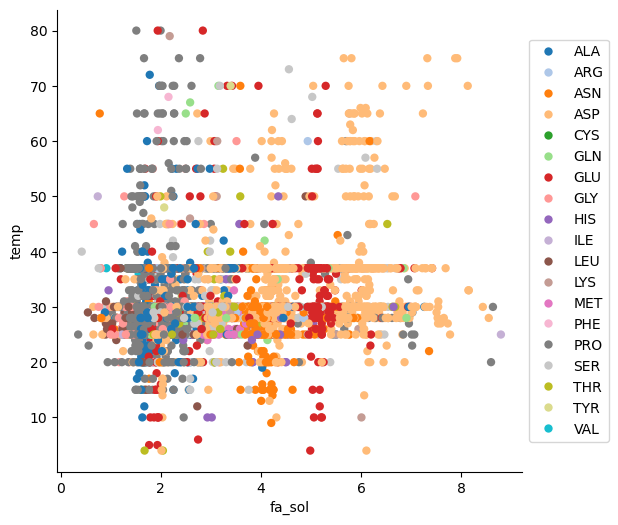

In [181]:
site_data = plotdf[plotdf['aln_res'].eq(84) & (plotdf['temp'] < 90)].copy()
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=site_data, 
                x='fa_sol', y='temp', hue='resname', hue_order=sorted(site_data['resname'].unique()), palette='tab20',
               linewidth=0)
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
sns.despine()

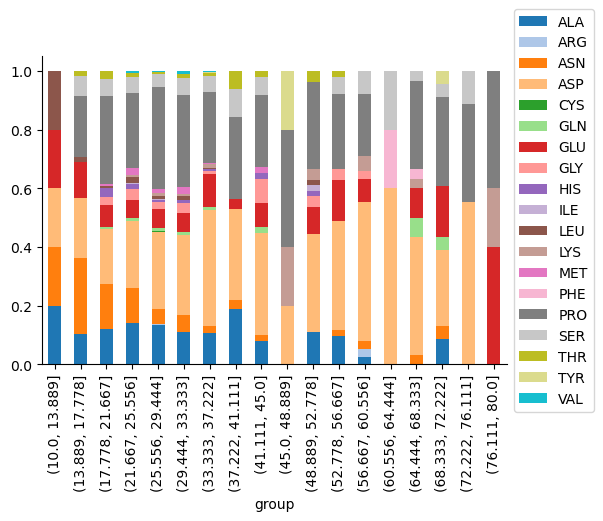

In [182]:
site_data['group'] = pd.cut(site_data['temp'], np.linspace(10, 80, 19))

fig, ax = plt.subplots(figsize=(6,4))
site_bar_data = site_data.groupby('group', observed=False)['resname'].value_counts().unstack().reindex(columns=sorted(site_data['resname'].unique())).fillna(1e-6)
site_bar_data.divide(site_bar_data.sum(1), axis=0).plot(kind='bar', stacked=True, ax=ax, color=list(sns.color_palette('tab20', n_colors=19)))
sns.despine()
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [183]:
# make tree
gtdb_tree = Tree('/data/mhoffert/genomes/GTDB_r214.1/bac120_r214.tree', format=1, quoted_node_names=True)

gtdb_tree.describe()

pruned = gtdb_tree.copy()
pruned.prune(site_data.dropna().index.get_level_values(0), preserve_branch_length=True)

pruned.describe()

prune_names_map = pd.Series()
for i, node in enumerate(pruned.traverse(strategy='levelorder')):
    if not node.is_leaf():
        prune_names_map.loc[node.name] = f'c{i:05d}'
        node.name = f'c{i:05d}'

Number of leaf nodes:	80789
Total number of nodes:	161577
Rooted:	Yes
Most distant node:	RS_GCF_003265155.1
Max. distance:	3.393161
Number of leaf nodes:	6529
Total number of nodes:	13057
Rooted:	Yes
Most distant node:	RS_GCF_900660515.1
Max. distance:	2.950539


In [184]:
resname_cmap = dict((r,i) for r,i in zip(sorted(plotdf.dropna()['resname'].unique()), sns.color_palette('tab20', n_colors=20)))

def plot_tree_with_annotations(tree, df, resname_col, metric_col, ogt_col, 
                                metric_cmap='gnuplot', ogt_cmap='bwr'):
    """
    Annotate tree tips with residue name, metric value, and OGT.
    
    Args:
        tree: ete3 Tree object
        df: DataFrame with index as leaf names
        resname_col: column name for residue
        metric_col: column name for metric (e.g., fa_atr)
        ogt_col: column name for OGT
        metric_cmap: colormap for metric
        ogt_cmap: colormap for OGT
    """
    # Normalize values for coloring
    metric_norm = mcolors.Normalize(vmin=df[metric_col].min(), vmax=df[metric_col].max())
    ogt_norm = mcolors.TwoSlopeNorm(vcenter=37, vmin=df[ogt_col].min(), vmax=df[ogt_col].max())
    metric_cmap = plt.cm.get_cmap(metric_cmap)
    ogt_cmap = plt.cm.get_cmap(ogt_cmap)
    
    for leaf in tree.traverse():
        ns = NodeStyle()
        # if not leaf.is_leaf():
        ns['size'] = 0
            
        if leaf.name in df.index:
            row = df.loc[leaf.name]

            # Residue name
            # res_face = TextFace(f" {row[resname_col]} ", fsize=8)
            # leaf.add_face(res_face, column=0, position="aligned")

            # Metric with color
            resname_val = row['resname']
            resname_color = mcolors.to_hex(resname_cmap[resname_val])
            resname_face = RectFace(width=100, height=1, fgcolor=resname_color, 
                                   bgcolor=resname_color)
            leaf.add_face(resname_face, column=0, position="aligned")
            
            
            # Metric with color
            metric_val = row[metric_col]
            metric_color = mcolors.to_hex(metric_cmap(metric_norm(metric_val)))
            metric_face = RectFace(width=100, height=1, fgcolor=metric_color, 
                                   bgcolor=metric_color)
            leaf.add_face(metric_face, column=1, position="aligned")
            
            # OGT with color
            ogt_val = row[ogt_col]
            ogt_color = mcolors.to_hex(ogt_cmap(ogt_norm(ogt_val)))
            ogt_face = RectFace( width=100, height=1,fgcolor=ogt_color, 
                               bgcolor=ogt_color)
            leaf.add_face(ogt_face, column=2, position="aligned")
            
        leaf.set_style(ns)
    
    # Tree style
    ts = TreeStyle()
    ts.mode = "c"
    ts.show_leaf_name = False
    ts.show_branch_length = False
    ts.show_branch_support = False
    
    return tree, ts

# Usage:
# tree = Tree("your_tree.nwk")
# tree, ts = plot_tree_with_annotations(tree, df, "residue", "fa_atr", "OGT")
# tree.render("tree_plot.png", tree_style=ts, w=800, h=200)
# # or tree.show(tree_style=ts) for interactive

/tmp/ipykernel_2037727/2384836414.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  metric_cmap = plt.cm.get_cmap(metric_cmap)
/tmp/ipykernel_2037727/2384836414.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  ogt_cmap = plt.cm.get_cmap(ogt_cmap)


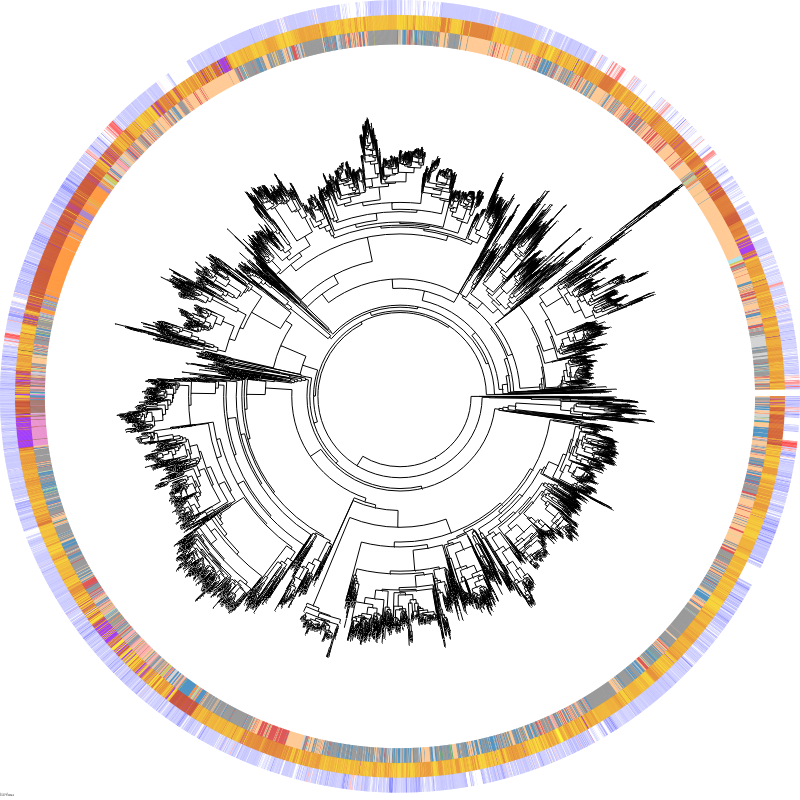

In [185]:
tree, ts = plot_tree_with_annotations(pruned, site_data.reset_index().set_index('uid'), "resname", "fa_sol", "temp")
tree.render("%%inline", tree_style=ts, w=800, h=800)

/tmp/ipykernel_2037727/707655993.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


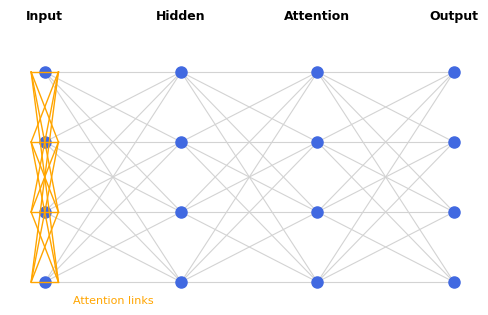

In [195]:
import matplotlib.pyplot as plt
import numpy as np

def draw_attention_network():
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.axis('off')

    # Positions for layers
    x = [0, 2, 4, 6]
    labels = ["Input", "Hidden", "Attention", "Output"]
    y_positions = np.linspace(0.5, 2.5, 4)

    # Draw nodes
    for i, xi in enumerate(x):
        for y in y_positions:
            ax.plot(xi, y, 'o', color='royalblue', markersize=8)
        ax.text(xi, 3, labels[i], ha='center', fontsize=9, weight='bold', zorder=2)

    # Connect layers
    for i in range(len(x) - 1):
        for y1 in y_positions:
            for y2 in y_positions:
                ax.plot([x[i], x[i+1]], [y1, y2], color='lightgray', lw=0.8, zorder=1)

    # Highlight attention connections (self-connections at layer 3)
    for y1 in y_positions:
        for y2 in y_positions:
            ax.plot([x[0]-0.2, x[0]+0.2], [y1, y2], color='orange', lw=1)

    ax.text(1, 0.3, "Attention links", color='orange', fontsize=8, ha='center')
    plt.tight_layout()
    plt.show()

# Example usage
draw_attention_network()


## PICs for fa_atr

In [1014]:
import numpy as np
from scipy import stats
from ete3 import Tree
from typing import Dict, Tuple, List
import pandas as pd

In [1033]:
from scipy.stats import spearmanr

In [1015]:
gtdb_tree = Tree('/data/mhoffert/genomes/GTDB_r214.1/bac120_r214.tree', format=1, quoted_node_names=True)

In [1016]:
gtdb_tree.describe()

Number of leaf nodes:	80789
Total number of nodes:	161577
Rooted:	Yes
Most distant node:	RS_GCF_003265155.1
Max. distance:	3.393161


In [1049]:
def compute_phylogenetic_contrasts(tree: Tree, 
                                   trait_values: Dict[str, float],
                                   standardize: bool = True) -> Tuple[np.ndarray, List[str]]:
    """
    Compute Phylogenetic Independent Contrasts (PICs) using Felsenstein's algorithm.
    
    Parameters:
    -----------
    tree : ete3.Tree
        Phylogenetic tree (must have branch lengths)
    trait_values : dict
        Dictionary mapping leaf names to trait values (e.g., {'species1': 25.5, ...})
    standardize : bool
        Whether to standardize contrasts by their standard deviation (recommended)
    
    Returns:
    --------
    contrasts : np.ndarray
        Array of independent contrasts
    node_names : list
        Labels for each contrast (for debugging)
    
    Notes:
    ------
    - Tree must be bifurcating (binary) and have branch lengths
    - Missing values are not allowed
    - Contrasts are computed in postorder traversal
    """
    
    # Make a copy to avoid modifying original tree
    t = tree.copy()
    
    # Check that all leaves have trait values
    leaf_names = set([leaf.name for leaf in t.iter_leaves()])
    trait_names = set(trait_values.keys())
    
    if not leaf_names.issubset(trait_names):
        missing = leaf_names - trait_names
        raise ValueError(f"Missing trait values for leaves: {missing}")
    
    # Storage for contrasts
    contrasts = []
    node_names = []
    
    # Postorder traversal: process leaves first, then internal nodes
    for node in t.traverse("postorder"):
        
        if node.is_leaf():
            # Store trait value at leaf
            node.add_feature("trait_value", trait_values[node.name])
            node.add_feature("trait_variance", 0.0)  # No variance at tips
            
        else:
            # Internal node: compute contrast from children
            children = node.get_children()
            
            if len(children) != 2:
                print(node)
                raise ValueError(f"Tree must be bifurcating. Node has {len(children)} children.")
            
            c1, c2 = children
            
            # Get trait values (either from tips or reconstructed ancestors)
            v1 = c1.trait_value
            v2 = c2.trait_value
            
            # Get branch lengths
            bl1 = c1.dist if c1.dist > 0 else 1e-6  # Avoid zero branch lengths
            bl2 = c2.dist if c2.dist > 0 else 1e-6
            
            # Get variances accumulated along branches
            var1 = c1.trait_variance + bl1
            var2 = c2.trait_variance + bl2
            
            # Compute contrast
            contrast = v1 - v2
            
            # Standard deviation of contrast
            contrast_sd = np.sqrt(var1 + var2)
            
            # Standardize contrast by its expected SD
            if standardize:
                standardized_contrast = contrast / contrast_sd
            else:
                standardized_contrast = contrast
            
            contrasts.append(standardized_contrast)
            node_names.append(f"{c1.name}_vs_{c2.name}")
            
            # Reconstruct ancestral state at this node (weighted average)
            # This is the squared-change parsimony estimate
            node_trait = (v1 * var2 + v2 * var1) / (var1 + var2)
            
            # Variance at this node (for propagating up the tree)
            node_variance = (var1 * var2) / (var1 + var2)
            
            node.add_feature("trait_value", node_trait)
            node.add_feature("trait_variance", node_variance)
    
    return np.array(contrasts), node_names

In [1058]:
fa_atr_dict = pd.Series(index=site_data.index.get_level_values(0),
          data=site_data['fa_elec'].values).to_dict()
temp_dict = pd.Series(index=site_data.index.get_level_values(0),
          data=site_data['temp'].values).to_dict()

In [1059]:
# for col in Xc.columns:
a,b = compute_phylogenetic_contrasts(pruned, 
                                     fa_atr_dict,
                                    standardize=True)
stat_contrasts = pd.Series(index=b, data=a)

a,b = compute_phylogenetic_contrasts(pruned, 
                                     temp_dict,
                                    standardize=True)
temp_contrasts = pd.Series(index=b, data=a)

# fig, ax = plt.subplots(figsize=(6,6))
# sns.scatterplot(x=sasa_contrasts, y=temp_contrasts, linewidth=0, alpha=0.05)
# ax.set_xlabel('SASA')
# ax.set_ylabel('temp')
print(spearmanr(stat_contrasts, temp_contrasts))

SignificanceResult(statistic=0.00703992050606, pvalue=0.5181459620019842)


In [1060]:
print(spearmanr(stat_contrasts, temp_contrasts))

SignificanceResult(statistic=0.00703992050606, pvalue=0.5181459620019842)


<Axes: xlabel='None', ylabel='None'>

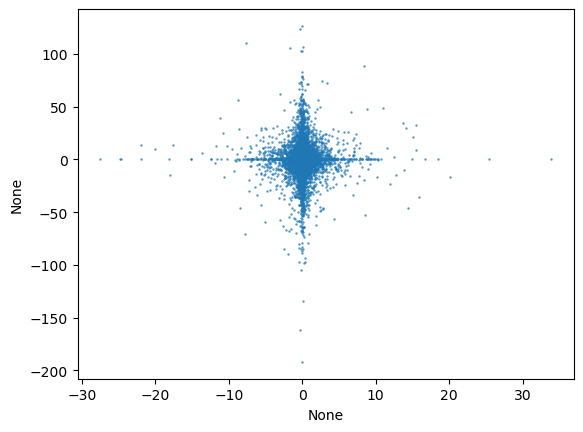

In [1061]:
sns.scatterplot(x=stat_contrasts, y=temp_contrasts,
               linewidth=0, alpha=0.75, s=3)

In [1045]:
temp_contrasts

RS_GCF_000092845.1_vs_RS_GCF_000384655.1     0.000000
RS_GCF_001049755.1_vs_RS_GCF_000223215.1     0.000000
RS_GCF_000316195.1_vs_c00090               -17.000000
c00051_vs_c00052                             6.649010
c00027_vs_RS_GCF_000518245.1                -3.554246
                                              ...    
RS_GCF_001027545.1_vs_RS_GCF_000020145.1     0.000000
c00025_vs_c00026                            16.527570
c00013_vs_c00014                            -4.577462
c00005_vs_c00006                           -13.312657
c00001_vs_c00002                            -6.785075
Length: 8475, dtype: float64

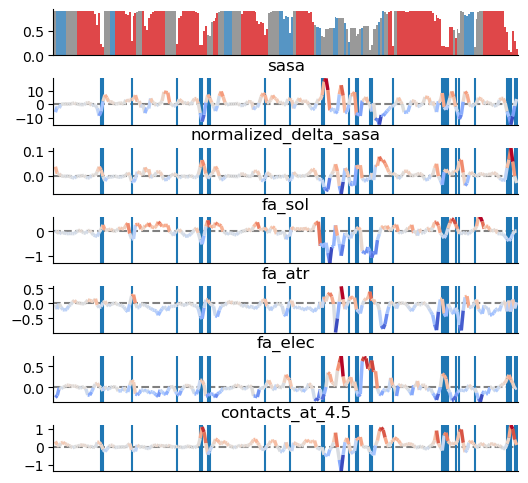

In [896]:
fig = plt.figure(figsize=(6,6))

 #.stack().reset_index().rename(columns={'level_1':'stat', 0:'value'})

ax1 = fig.add_subplot(7,1,1)
ax1.bar(grouped['aln_res'], (plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique())).sort_index(),
       color=grouped['ss_color'], width=1, alpha=0.8, zorder=1)


i = 2
for col in contrast_data.drop('aln_res', axis=1).columns:
    ax = fig.add_subplot(7,1,i, sharex=ax1)

    for index, item in (plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique())).sort_index().items():
        if item < 0.50:
            ax.axvline(index)
        
    
    ax.axhline(0, color='gray', linestyle='--', zorder=0)
            
    x = contrast_data['aln_res']
    y=contrast_data.set_index('aln_res')[col] # * (plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()))
    y_smooth = y.rolling(window=3, center=True).mean()
    
    # Plotting
    norm = mpl.colors.TwoSlopeNorm(vcenter=0, vmin=y_smooth.min(), vmax=y_smooth.max())
    colors = y_smooth.apply(norm).map(mpl.colormaps['coolwarm']).apply(mpl.colors.to_hex).values
    
    # Build segments for LineCollection
    points = np.array([x, y_smooth]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Normalize and color map
    norm = mpl.colors.TwoSlopeNorm(vcenter=0, vmin=y_smooth.min(), vmax=y_smooth.max())
    lc = LineCollection(
        segments,
        cmap='coolwarm',
        norm=norm,
        linewidth=2.5
    )
    lc.set_array(y_smooth.values)
    ax.add_collection(lc)
    
    # plt.scatter(x, y_smooth, label='Smoothed Curve (Spline)', c=colors, s=3)    
    sns.despine()
    ax.set_title(col)
    ax.set_xlabel('')
    # ax.set_ylabel(col, rotation=0, )
    

        # Adjust limits
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y_smooth.min(), y_smooth.max())
    
    if i != 6:
        ax.set_xticks([])


    i += 1
    
fig.subplots_adjust(hspace=0.5)

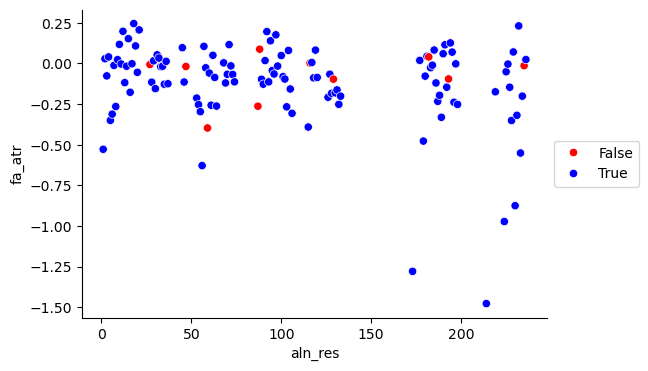

In [811]:
fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(data=contrast_data.mask(~contrast_data['aln_res'].isin(conserved_residues[conserved_residues].index)),
                x='aln_res', 
                y='fa_atr', 
                hue=single_plot_data1['sasa'] < 100, palette=['r', 'b'])
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
sns.despine()

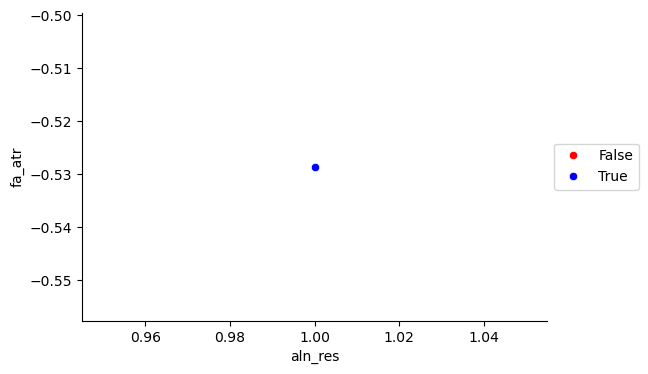

In [807]:
fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(data=contrast_data.mask(~contrast_data['aln_res'].isin(conserved_residues[conserved_residues])),
                x='aln_res', 
                y='fa_atr', 
                hue=single_plot_data1['sasa'] < 100, palette=['r', 'b'])
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
sns.despine()

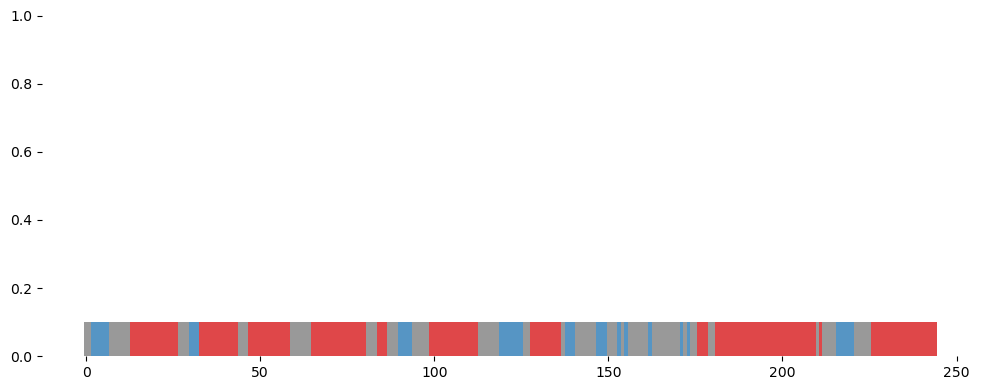

In [830]:

fig, ax = plt.subplots(figsize=(10, 4))

# # Background: domain blocks
# domains = [
#     (1, 29, 'gray'),
#     (30, 67, 'yellow'),
#     (68, 117, 'gray'),
#     (118, 160, 'green'),
#     (161, 214, 'gray')
# ]
# for start, end, color in domains:
#     ax.axvspan(start, end, color=color, alpha=0.25, zorder=0)

# # Plot ΔSASA (continuous feature)
# ax.plot(grouped['aln_res'], grouped['delta_sasa'],
#         color='black', lw=1.5, label='Avg ΔSASA', zorder=2)

# Overlay secondary structure as a colored bar
ax.bar(grouped['aln_res'], 0.1,
       color=grouped['ss_color'], width=1, alpha=0.8, zorder=1)

# # ---- Aesthetic adjustments ----
# ax.set_xlabel("Aligned residue position")
# ax.set_ylabel("ΔSASA (avg)")
# ax.set_xlim(grouped['aln_res'].min(), grouped['aln_res'].max())
# ax.set_title("Residue-level structural map")

# # Legend for secondary structure
# handles = [plt.Line2D([0], [0], color=c, lw=6, label=ss)
#            for ss, c in ss_color_map.items()]
# ax.legend(handles=handles, title="Secondary structure", loc='upper right')

sns.despine(left=True, bottom=True)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [826]:
grouped

,aln_res,delta_sasa,secondary_structure,ss_color
0,0.0,96.777897,L,gray
1,1.0,159.432113,L,gray
2,2.0,206.919113,E,#2c7bb6
3,3.0,197.237535,E,#2c7bb6
4,4.0,189.541583,E,#2c7bb6
...,...,...,...,...
240,240.0,110.362447,H,#d7191c
241,241.0,148.03622,H,#d7191c
242,242.0,101.222732,H,#d7191c
243,243.0,100.01741,H,#d7191c


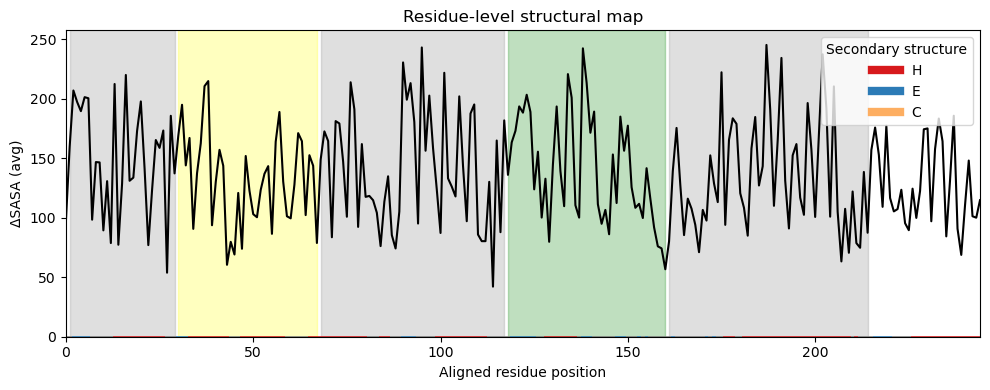

In [769]:
plot_residue_map(plotdf)

/tmp/ipykernel_1597161/3828832729.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=contrast_data.reset_index(),
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


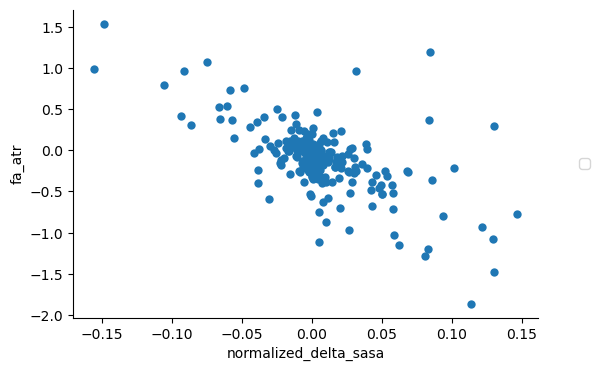

In [750]:
fig,ax = plt.subplots(figsize=(6,4))
sns.scatterplot(data=contrast_data.reset_index(),
            x='normalized_delta_sasa',
            y='fa_atr', 
            # hue='temp', 
            palette='bwr', linewidth=0)
lgd = ax.legend(loc='center', bbox_to_anchor=(1.1, 0.5))
sns.despine()

<Axes: xlabel='fa_elec', ylabel='normalized_delta_sasa'>

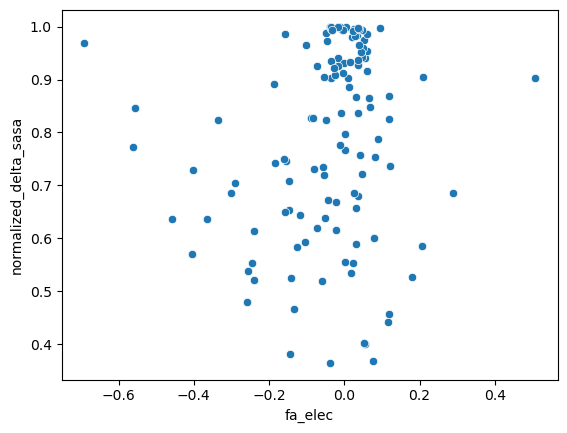

In [762]:
sns.scatterplot(x=single_plot_data1['fa_elec'] - single_plot_data2['fa_elec'], 
                y=single_plot_data1['normalized_delta_sasa'].mask(~(plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()) > 0.90)), 
                )
# sns.histplot(single_plot_data2['fa_atr'], palette=['Prefs'])

<Axes: xlabel='fa_atr', ylabel='normalized_delta_sasa'>

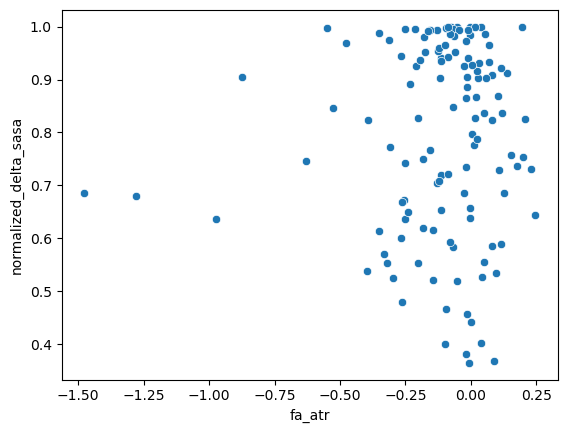

In [752]:
sns.scatterplot(x=single_plot_data1['fa_atr'] - single_plot_data2['fa_atr'], 
                y=single_plot_data1['normalized_delta_sasa'].mask(~(plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()) > 0.90)), 
                )

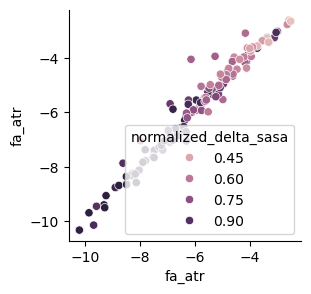

In [744]:
fig, ax = plt.subplots(figsize=(3,3))
sns.scatterplot(x=single_plot_data1['fa_atr'],
                y=single_plot_data2['fa_atr'].mask(~(plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()) > 0.90)), hue=single_plot_data1['normalized_delta_sasa']
                )
sns.despine()
# plt.plot((0, 100), (0, 100))

In [757]:
means = plotdf.reset_index().groupby(['uid', 'aln_res'])['fa_atr'].first().unstack().mean()
conserved_residues = plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()) > 0.90

<Axes: xlabel='0', ylabel='temp'>

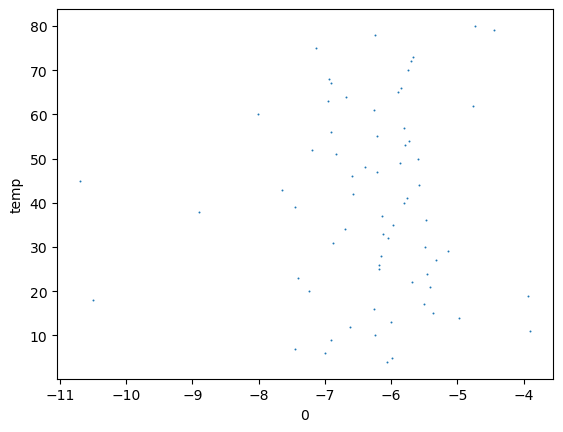

In [760]:
bias_df = (plotdf.reset_index().groupby(['temp', 'aln_res'])['fa_atr'].first().unstack()).stack().reset_index()
sns.scatterplot(data=bias_df[bias_df['aln_res'].isin(conserved_residues[conserved_residues])],
                x=0, y='temp', 
               linewidth=0, s=2)#.mean(1)

<Axes: xlabel='fa_atr', ylabel='Count'>

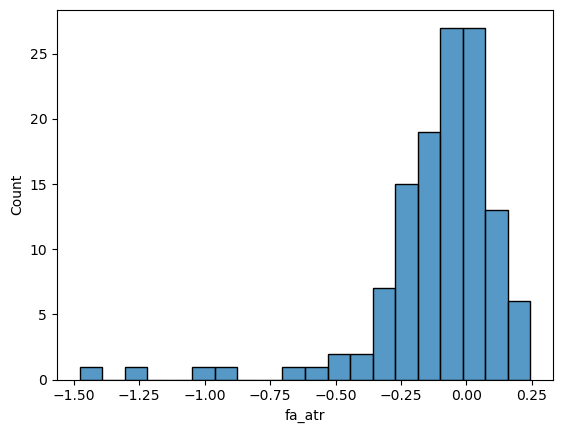

In [703]:
sns.histplot((single_plot_data1['fa_atr'] - single_plot_data2['fa_atr']).mask(~(plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()) > 0.90)))

<Axes: xlabel='fa_atr', ylabel='normalized_delta_sasa'>

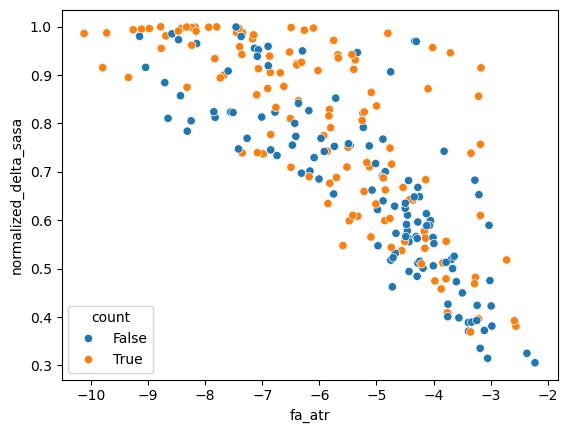

In [697]:
sns.scatterplot(x=single_plot_data2['fa_atr'], 
                y=single_plot_data2['normalized_delta_sasa'], 
                hue=plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()) > 0.90
                )

<Axes: xlabel='None', ylabel='temp'>

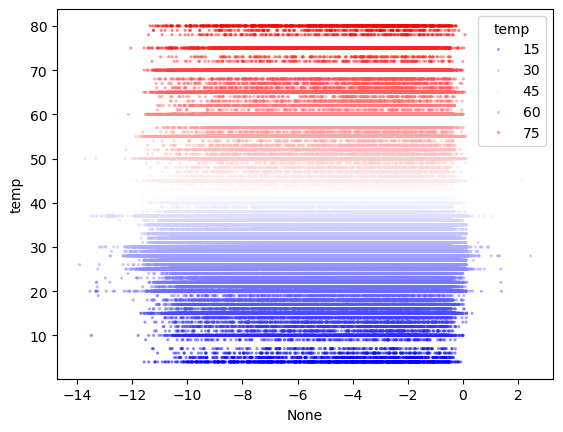

In [666]:
sns.scatterplot(data=plotdf,
                x=plotdf['fa_atr'], 
                y=plotdf['temp'],
                hue='temp', palette='bwr',
                linewidth=0, alpha=0.5,s=5)

In [694]:
plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique())

aln_res
192.0    0.908789
92.0     0.908682
128.0    0.908682
131.0    0.908682
130.0    0.908682
           ...   
243.0    0.120972
166.0    0.120009
239.0    0.112515
240.0    0.070121
244.0    0.050423
Name: count, Length: 245, dtype: float64

In [667]:
import numpy as np
import pandas as pd

# Simulate 10 observations per group
np.random.seed(0)
S1_A = np.random.normal(10, 2, 10)
S1_B = np.random.normal(8, 2, 10)

S2_A = np.random.normal(50, 5, 10)
S2_B = np.random.normal(48, 5, 10)

# Original statistics as DataFrame
df = pd.DataFrame({
    'S1_A': S1_A, 'S1_B': S1_B,
    'S2_A': S2_A, 'S2_B': S2_B
})

# Compute deltas (differences between groups)
df['Delta1'] = df['S1_A'] - df['S1_B']
df['Delta2'] = df['S2_A'] - df['S2_B']

# Check correlation
print("Correlation of deltas:", df[['Delta1','Delta2']].corr().iloc[0,1])


Correlation of deltas: 0.2635810841081134


## Testing pLDDT

In [47]:
pdbs = glob.glob('./../data/processed_structures/*.pdb')

In [46]:
def extract_plddt(pdb_path):
    parser = PDB.PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_path)
    
    plddt_scores = []
    residue_indices = []

    for model in structure:
        for chain in model:
            for residue in chain:
                # pLDDT is stored in the B-factor field of each atom. 
                # We typically take the value from the CA (Alpha Carbon) 
                # as the representative score for the residue.
                if "CA" in residue:
                    plddt = residue["CA"].get_bfactor()
                    plddt_scores.append(plddt)
                    residue_indices.append(residue.get_id()[1])
    
    return np.array(residue_indices), np.array(plddt_scores)

# Example usage:
# res_idx, scores = extract_plddt("your_protein.pdb")
# print(f"Average pLDDT: {np.mean(scores):.2f}")

In [60]:
filtered.columns

Index(['Unnamed: 0', 'Position', 'Contacts at 4.5 Å', 'SASA', 'uid',
       'total_score', 'avg_deg_4_5', 'avg_deg_8', 'avg_sc_nbrs_res_summary',
       'bb_internal_hbonds', 'bbsc_internal_hbonds', 'cav_vol', 'dslf_fa13',
       'fa_atr', 'fa_dun', 'fa_elec', 'fa_intra_rep', 'fa_intra_sol_xover4',
       'fa_rep', 'fa_sol', 'hbond_bb_sc', 'hbond_lr_bb', 'hbond_sc',
       'hbond_sr_bb', 'internal_hbonds', 'lk_ball_wtd', 'nonpolar_sasa',
       'omega', 'p_aa_pp', 'packstat', 'polar_sasa', 'pro_close',
       'rama_prepro', 'ref', 'sasa', 'sc_internal_hbonds', 'total_cc_contacts',
       'yhh_planarity', '%S', '%L', '%H', 'length', 'avg_cc_contacts_per_res',
       'temp', 'mean_temp', 'seq_length', 'bitscore', 'C', 'L', 'N', 'P',
       'max_structure_length', 'lid_bitscore'],
      dtype='object')

In [85]:
filtered['temp_group'] = pd.cut(filtered['temp'], np.linspace(0, 80, 10))
filtered_sample = filtered.groupby('temp_group', observed=True).apply(lambda x: x.sample(np.min([len(x), 50]), replace=False))

In [78]:
results = []
for i, pdb in enumerate(pdbs):
    if i % 5 == 0:
        display(i)
        clear_output(wait=True)
    uid = pdb.split('/')[-1].split('_A')[0]
    if uid in filtered_sample'uid'].values:
        data = pd.DataFrame(extract_plddt(pdb)).T.rename(columns={0:'position', 1:'pLDDT'}).mean()
        data.loc['temp'] = filtered.set_index('uid').loc[uid, 'temp']
        data.loc['name'] = uid
        results.append(data)

9340

<Axes: xlabel='position', ylabel='pLDDT'>

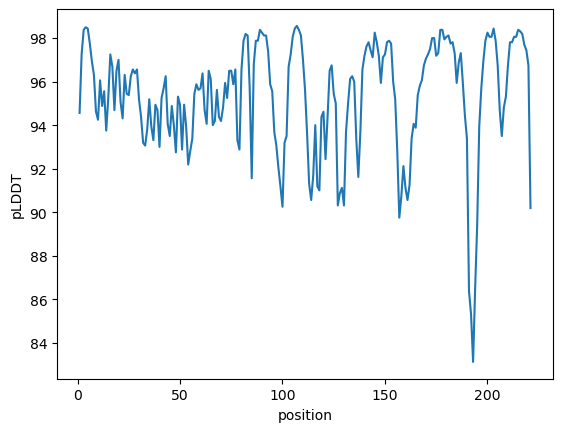

In [86]:
sns.lineplot(data=pd.DataFrame(extract_plddt(pdb)).T.rename(columns={0:'position', 1:'pLDDT'}),
             x='position', y='pLDDT')

In [87]:
pd.DataFrame(extract_plddt(pdb)).T.rename(columns={0:'position', 1:'pLDDT'})

,position,pLDDT
0,1.0,94.56
1,2.0,97.25
2,3.0,98.38
3,4.0,98.50
4,5.0,98.44
...,...,...
216,217.0,98.19
217,218.0,97.69
218,219.0,97.44
219,220.0,96.75


In [79]:
plotdf = pd.concat(results, axis=1).T

<Axes: xlabel='temp', ylabel='pLDDT'>

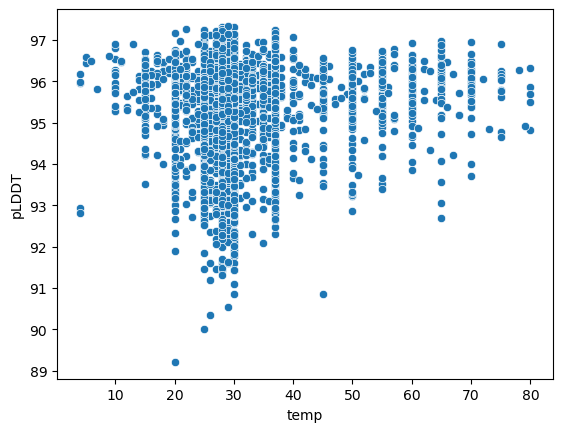

In [80]:
sns.scatterplot(data=plotdf, x='temp', y='pLDDT')